# Библиотеки

In [1]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
from tqdm.auto import tqdm
import threading
import itertools
import sys
import glob
import numpy as np
from tqdm import tqdm
import phik
import seaborn as sns

In [2]:
import matplotlib
print(matplotlib.__version__)
print(matplotlib.__file__)

3.10.8
c:\Проекты\project_ml_monopoly\venv\lib\site-packages\matplotlib\__init__.py


# Предобработка

In [3]:
# 📁 Папка, где лежат parquet-чанки
CHUNKS_DIR = r"C:\Проекты\project_ml_monopoly\notebooks\ai_продукты"

def load_all_chunks_to_one_df(chunks_dir: str) -> pd.DataFrame:
    # Смотрим все файлы си эс ви в папке
    pattern = os.path.join(chunks_dir, "*.csv")
    files = sorted(glob.glob(pattern))
    # Заглушка
    if not files:
        raise FileNotFoundError(f"Не найдено ни одного файла по маске: {pattern}")

    print(f"Найдено csv-файлов: {len(files)}")
    # Складываем все из них в датасет
    dfs = []
    for file in files:
        df_chunk = pd.read_csv(file)
        dfs.append(df_chunk)
    # Складываем все из них в датасет
    df_full = pd.concat(dfs, ignore_index=True)

    print(f"Итоговый размер: {df_full.shape[0]:,} строк × {df_full.shape[1]} колонок")
    mem_mb = df_full.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"Память: ~{mem_mb:.2f} MB")

    return df_full


if __name__ == "__main__":
    df_product = load_all_chunks_to_one_df(CHUNKS_DIR)


Найдено csv-файлов: 13


C:\Users\SIMukovoz\AppData\Local\Temp\ipykernel_173476\424623191.py:16: DtypeWarning: Columns (65) have mixed types. Specify dtype option on import or set low_memory=False.
  df_chunk = pd.read_csv(file)
C:\Users\SIMukovoz\AppData\Local\Temp\ipykernel_173476\424623191.py:16: DtypeWarning: Columns (65) have mixed types. Specify dtype option on import or set low_memory=False.
  df_chunk = pd.read_csv(file)
C:\Users\SIMukovoz\AppData\Local\Temp\ipykernel_173476\424623191.py:16: DtypeWarning: Columns (65) have mixed types. Specify dtype option on import or set low_memory=False.
  df_chunk = pd.read_csv(file)
C:\Users\SIMukovoz\AppData\Local\Temp\ipykernel_173476\424623191.py:16: DtypeWarning: Columns (65) have mixed types. Specify dtype option on import or set low_memory=False.
  df_chunk = pd.read_csv(file)
C:\Users\SIMukovoz\AppData\Local\Temp\ipykernel_173476\424623191.py:16: DtypeWarning: Columns (65) have mixed types. Specify dtype option on import or set low_memory=False.
  df_chunk 

Итоговый размер: 742,222 строк × 76 колонок
Память: ~3006.19 MB


In [4]:
df_product = df_product.drop_duplicates()

In [5]:
df_cut = df_product[['Код товара',
                     'МНН',
                     'Форма выпуска',
                     'Лекарственная форма',
                     'Группа',
                     'Препарат предметно-количественного учета',
                     'Сезонность 1',
                     'Условия хранения',
                     'Рейтинг внешний',
                     'ЖНВЛС',
                     'ЭО общая',
                     'Статус',
                     'Обязательный ассортимент']]

In [6]:
# 📁 Папка, где лежат parquet-чанки
CHUNKS_DIR = r"C:\Проекты\project_ml_monopoly\notebooks\ai_stock_3years_chunks"

def load_all_chunks_to_one_df(chunks_dir: str) -> pd.DataFrame:
    pattern = os.path.join(chunks_dir, "*.csv")
    files = sorted(glob.glob(pattern))

    if not files:
        raise FileNotFoundError(f"Не найдено ни одного файла по маске: {pattern}")

    print(f"Найдено csv-файлов: {len(files)}")

    dfs = []
    for file in files:
        df_chunk = pd.read_csv(file)
        dfs.append(df_chunk)

    df_full = pd.concat(dfs, ignore_index=True)

    print(f"Итоговый размер: {df_full.shape[0]:,} строк × {df_full.shape[1]} колонок")
    mem_mb = df_full.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"Память: ~{mem_mb:.2f} MB")

    return df_full


if __name__ == "__main__":
    df_all = load_all_chunks_to_one_df(CHUNKS_DIR)


Найдено csv-файлов: 13
Итоговый размер: 7,029,003 строк × 19 колонок
Память: ~4811.60 MB


In [7]:
# import pyodbc
# import pandas as pd
# import time
# import os
# import threading
# import itertools
# import sys

# # 🔐 Подключение
# uid = "ii_user"
# pwd = "Vjoi970N"
# driver = "{ODBC Driver 18 for SQL Server}"
# server = "192.168.200.196,59197"
# database = "dwh_cube"

# SCHEMA_NAME = "dbo"
# VIEW_NAME = "AI_stock_farm_market_table"

# # 📁 Папка для файлов
# OUTPUT_DIR = "ai_dsm"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# OUTPUT_FILE = os.path.join(OUTPUT_DIR, "ai.parquet")


# # ============================================================
# # 🎛 Анимация "запрос выполняется..."
# # ============================================================
# class Spinner:
#     def __init__(self, message="⏳ Выполняется SQL-запрос... "):
#         self.spinner = itertools.cycle(["|", "/", "-", "\\"])
#         self.running = False
#         self.thread = None
#         self.message = message

#     def start(self):
#         self.running = True
#         self.thread = threading.Thread(target=self.animate)
#         self.thread.start()

#     def animate(self):
#         while self.running:
#             sys.stdout.write(f"\r{self.message}{next(self.spinner)}")
#             sys.stdout.flush()
#             time.sleep(0.2)

#     def stop(self):
#         self.running = False
#         if self.thread:
#             self.thread.join()
#         sys.stdout.write("\r" + " " * 50 + "\r")  # очистить строку


# # ============================================================
# # 🚀 Основной код
# # ============================================================
# def main():
#     conn = None
#     try:
#         conn = pyodbc.connect(
#             f"DRIVER={driver};SERVER={server};DATABASE={database};"
#             f"UID={uid};PWD={pwd};TrustServerCertificate=yes;",
#             autocommit=True,
#         )
#         print("✅ Соединение с БД установлено\n")

#         sql = f"""
#         select 
#         *
#         from v$sros_dict
#         """

#         # ⏳ Запускаем анимацию
#         spinner = Spinner()
#         spinner.start()
#         t0 = time.time()

#         df = pd.read_sql(sql, conn)

#         spinner.stop()
#         dt = time.time() - t0

#         rows = len(df)
#         print(f"📥 Получено строк: {rows:,}")
#         print(f"⏱ SQL-время: {dt:.1f} сек")

#         if rows == 0:
#             print("⚠️ Нет данных для сохранения.")
#             return

#         # 💾 Сохраняем в Parquet
#         t1 = time.time()
#         df.to_parquet(OUTPUT_FILE, index=False, engine="pyarrow")
#         save_dt = time.time() - t1

#         file_size_mb = os.path.getsize(OUTPUT_FILE) / (1024 * 1024)

#         print(f"\n✅ ВЫГРУЗКА ЗАВЕРШЕНА!")
#         print(f"💾 Файл: {OUTPUT_FILE}")
#         print(f"📦 Размер: {file_size_mb:.1f} MB")
#         print(f"⏱ Время сохранения: {save_dt:.1f} сек")
#         print(f"⏱ Общее время: {(dt + save_dt):.1f} сек")

#     except Exception as e:
#         print("\n❌ Ошибка при выгрузке:")
#         print(e)

#     finally:
#         if conn:
#             conn.close()
#             print("\n🔚 Соединение с БД закрыто")


# if __name__ == "__main__":
#     main()

# Убираем выведёнышей

In [8]:
df_all.shape

(7029003, 19)

In [9]:
df_all = df_all.drop(['Остаток общий', 'Количество Ирбит', 'Остаток в пути'], axis =1)

In [10]:
df = df_all[df_all['Активный КАГ'] == 'Да']

In [11]:
df.shape

(4590901, 16)

In [12]:
df = pd.merge(df, df_cut, how='left', on='Код товара')

# Добавляем сцепку с ДСМ

In [13]:
dsm = pd.read_parquet(r'C:\Проекты\project_ml_monopoly\notebooks\ai_dsm\ai_gc_dsm.parquet')

In [14]:
dsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15481 entries, 0 to 15480
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   PRODUCT_ID  15481 non-null  object
 1   CODE        15481 non-null  object
 2   CAG_ID      15481 non-null  object
 3   NAME        15481 non-null  object
 4   NAME_CAG    15481 non-null  object
 5   CD_IAS      15481 non-null  object
 6   CD_U        15481 non-null  object
 7   CREATED     15481 non-null  object
dtypes: object(8)
memory usage: 967.7+ KB


In [15]:
df_for_dsm = df.copy()

In [16]:
df_for_dsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5886581 entries, 0 to 5886580
Data columns (total 28 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   Дата                                      object 
 1   CAG_ID                                    object 
 2   Код КАГ                                   int64  
 3   Имя КАГ                                   object 
 4   Активный КАГ                              object 
 5   Код товара                                object 
 6   Наименование у нас                        object 
 7   ГК (остатки гранд капитала)               int64  
 8   Пульс (остатки пульса)                    int64  
 9   Катрен (остатки катрена)                  int64  
 10  Протек (остатки протека)                  int64  
 11  Фармкомплект (остатки фармкомплекта)      int64  
 12  Цена пульса                               float64
 13  Цена катрена                              float64
 14  Це

In [17]:
df_for_dsm = pd.merge(df_for_dsm, dsm[['CODE', 'CD_IAS']], left_on = 'Код товара', right_on = 'CODE', how = 'inner').drop('CODE', axis = 1)

In [18]:
rare_situation = df_for_dsm.groupby(by = 'Код КАГ', as_index = False)['CD_IAS'].nunique()

In [19]:
df_for_dsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4149779 entries, 0 to 4149778
Data columns (total 29 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   Дата                                      object 
 1   CAG_ID                                    object 
 2   Код КАГ                                   int64  
 3   Имя КАГ                                   object 
 4   Активный КАГ                              object 
 5   Код товара                                object 
 6   Наименование у нас                        object 
 7   ГК (остатки гранд капитала)               int64  
 8   Пульс (остатки пульса)                    int64  
 9   Катрен (остатки катрена)                  int64  
 10  Протек (остатки протека)                  int64  
 11  Фармкомплект (остатки фармкомплекта)      int64  
 12  Цена пульса                               float64
 13  Цена катрена                              float64
 14  Це

In [20]:
# Находим самый частый CD_IAS для каждого КАГ
most_frequent = df_for_dsm.groupby(['Код КАГ', 'CD_IAS']).size().reset_index(name='count') \
                          .sort_values('count', ascending=False) \
                          .drop_duplicates(subset='Код КАГ', keep='first') \
                          .set_index('Код КАГ')['CD_IAS']

# Заменяем все CD_IAS на самый частый через map
df_for_dsm['CD_IAS'] = df_for_dsm['Код КАГ'].map(most_frequent)

In [21]:
t = df_for_dsm.groupby(by = 'Код КАГ', as_index = False)['CD_IAS'].nunique()
display(t[t['CD_IAS'] >1])

,Код КАГ,CD_IAS


In [22]:
df_for_dsm.head()

,Дата,CAG_ID,Код КАГ,Имя КАГ,Активный КАГ,Код товара,Наименование у нас,ГК (остатки гранд капитала),Пульс (остатки пульса),Катрен (остатки катрена),...,Группа,Препарат предметно-количественного учета,Сезонность 1,Условия хранения,Рейтинг внешний,ЖНВЛС,ЭО общая,Статус,Обязательный ассортимент,CD_IAS
0,2025-02-01,880000000001031E,8688,ФУРАДОНИН АВЕКСИМА таб. 50мг №20,Да,008312,Фурадонин Авексима таб. 50мг №20,50414,0,0,...,Медикаменты: твердые лекарственные формы,Нет,Без сезонности,от +15 до +25 градусов,3693.0,Нет,4271.0,Активен,Нет,45978
1,2025-02-01,880000000001031E,8688,ФУРАДОНИН АВЕКСИМА таб. 50мг №20,Да,008312,Фурадонин Авексима таб. 50мг №20,50414,0,0,...,Медикаменты: твердые лекарственные формы,Нет,Без сезонности,от +15 до +25 градусов,3693.0,Нет,4271.0,Активен,Нет,45978
2,2025-02-01,880000000001031E,8688,ФУРАДОНИН АВЕКСИМА таб. 50мг №20,Да,008312,Фурадонин Авексима таб. 50мг №20,50414,0,0,...,Медикаменты: твердые лекарственные формы,Нет,Без сезонности,от +15 до +25 градусов,3693.0,Нет,4271.0,Активен,Нет,45978
3,2025-02-01,880000000001031E,8688,ФУРАДОНИН АВЕКСИМА таб. 50мг №20,Да,008312,Фурадонин Авексима таб. 50мг №20,50414,0,0,...,Медикаменты: твердые лекарственные формы,Нет,Без сезонности,от +15 до +25 градусов,3693.0,Нет,4271.0,Активен,Нет,45978
4,2025-02-01,880000000000EFD6,3752,Камфорное масло д/нар пр. 10% 30мл /Йодные тех...,Да,035777,Камфорное масло д/нар пр. 10% 30мл,6387,0,0,...,Медикаменты: жидкие лекарственные формы,Нет,Без сезонности,от +15 до +25 градусов,7669.0,Нет,312.0,Активен,Да,112502


# Убираем лишине столбцы

In [23]:
df_to_model = df.drop(['Цена пульса', 'Цена катрена', 'Цена протека', 'Цена фармкомплекта', 'Активный КАГ'], axis = True)

# Дубли

In [24]:
df_to_model.shape

(5886581, 23)

In [25]:
df_to_model = df_to_model.drop_duplicates()

In [26]:
df_to_model.shape

(4591502, 23)

In [27]:
df_to_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4591502 entries, 0 to 5886580
Data columns (total 23 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   Дата                                      object 
 1   CAG_ID                                    object 
 2   Код КАГ                                   int64  
 3   Имя КАГ                                   object 
 4   Код товара                                object 
 5   Наименование у нас                        object 
 6   ГК (остатки гранд капитала)               int64  
 7   Пульс (остатки пульса)                    int64  
 8   Катрен (остатки катрена)                  int64  
 9   Протек (остатки протека)                  int64  
 10  Фармкомплект (остатки фармкомплекта)      int64  
 11  МНН                                       object 
 12  Форма выпуска                             object 
 13  Лекарственная форма                       object 
 14  Группа 

# Смена названий столбцов

In [28]:
df_to_model.columns = [
    'date', 
    'cag_id',          # Added this to match column index 1
    'code_kag', 
    'name_kag', 
    'code_product', 
    'name_product', 
    'gk_stock', 
    'puls_stock', 
    'katren_stock', 
    'protek_stock', 
    'farm_stock',
    'МНН',
    'Форма выпуска',
    'Лекарственная форма',
    'Группа',
    'Препарат предметно-количественного учета',
    'Сезонность 1',
    'Условия хранения',
    'Рейтинг внешний',
    'ЖНВЛС',
    'ЭО общая',
    'Статус',
    'Обязательный ассортимент'
]

In [29]:
df_to_model.columns

Index(['date', 'cag_id', 'code_kag', 'name_kag', 'code_product',
       'name_product', 'gk_stock', 'puls_stock', 'katren_stock',
       'protek_stock', 'farm_stock', 'МНН', 'Форма выпуска',
       'Лекарственная форма', 'Группа',
       'Препарат предметно-количественного учета', 'Сезонность 1',
       'Условия хранения', 'Рейтинг внешний', 'ЖНВЛС', 'ЭО общая', 'Статус',
       'Обязательный ассортимент'],
      dtype='object')

# Приведение к праивльным типам данных

In [30]:
df_to_model['date'] = pd.to_datetime(df_to_model['date'])

In [31]:
df_to_model['code_kag'] = df_to_model['code_kag'].astype(str)

In [32]:
df_to_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4591502 entries, 0 to 5886580
Data columns (total 23 columns):
 #   Column                                    Dtype         
---  ------                                    -----         
 0   date                                      datetime64[ns]
 1   cag_id                                    object        
 2   code_kag                                  object        
 3   name_kag                                  object        
 4   code_product                              object        
 5   name_product                              object        
 6   gk_stock                                  int64         
 7   puls_stock                                int64         
 8   katren_stock                              int64         
 9   protek_stock                              int64         
 10  farm_stock                                int64         
 11  МНН                                       object        
 12  Форма выпуска      

# Замена пропусков в ДФ 

In [33]:
df_to_model.isna().sum()

date                                              0
cag_id                                            0
code_kag                                          0
name_kag                                          0
code_product                                      0
name_product                                      0
gk_stock                                          0
puls_stock                                        0
katren_stock                                      0
protek_stock                                      0
farm_stock                                        0
МНН                                         1016386
Форма выпуска                               1014639
Лекарственная форма                             377
Группа                                            0
Препарат предметно-количественного учета          0
Сезонность 1                                  10700
Условия хранения                              30566
Рейтинг внешний                               44539
ЖНВЛС       

* Замена пропусков не требуется

# Объединяем по КАГ

In [34]:
df_sum = df_to_model.groupby(['date', 'code_kag'], sort=False)[['puls_stock', 'gk_stock', 'katren_stock', 'protek_stock', 'farm_stock']].sum()

In [35]:
masked = df_to_model[['date', 'code_kag'] + ['puls_stock', 'gk_stock', 'katren_stock', 'protek_stock', 'farm_stock']].copy()

In [36]:
df_max = df_to_model.groupby(['date', 'code_kag'], sort=False)[['puls_stock', 'gk_stock', 'katren_stock', 'protek_stock', 'farm_stock']].max()
df_min = df_to_model.groupby(['date', 'code_kag'], sort=False)[['puls_stock', 'gk_stock', 'katren_stock', 'protek_stock', 'farm_stock']].min()

In [37]:
idx = df_sum.index
df_max = df_max.reindex(idx)
df_min = df_min.reindex(idx)

In [38]:
is_dedup = df_max.eq(df_min) | df_max.isna()

In [39]:
result = df_sum.mask(is_dedup, df_max.fillna(0))

In [40]:
result = result.reset_index()

In [41]:
result['code_kag'] = result['code_kag'].astype(int)

In [42]:
t['CD_IAS'].unique()

array([1])

In [43]:
result

,date,code_kag,puls_stock,gk_stock,katren_stock,protek_stock,farm_stock
0,2025-02-01,7439,0,73,0,0,0
1,2025-02-01,8688,0,50414,0,0,0
2,2025-02-01,2793,0,2503,0,0,0
3,2025-02-01,3752,0,6387,0,0,0
4,2025-02-01,15875,0,804,0,0,0
...,...,...,...,...,...,...,...
3110774,2026-02-12,25873,0,120,3207,2485,0
3110775,2026-02-12,2829,0,111,0,0,0
3110776,2026-02-12,19076,0,4084,215,641,0
3110777,2026-02-12,18365,7585,246,402,2184,797


In [44]:
df_right = df_for_dsm[['Код КАГ','CD_IAS']].drop_duplicates(subset='Код КАГ')

In [45]:
mapping = df_right.set_index('Код КАГ')['CD_IAS']
result['CD_IAS'] = result['code_kag'].map(mapping)
result = result[result['CD_IAS'].notna()]  # inner join эффект

In [46]:
result

,date,code_kag,puls_stock,gk_stock,katren_stock,protek_stock,farm_stock,CD_IAS
0,2025-02-01,7439,0,73,0,0,0,2697
1,2025-02-01,8688,0,50414,0,0,0,45978
2,2025-02-01,2793,0,2503,0,0,0,159984
3,2025-02-01,3752,0,6387,0,0,0,112502
4,2025-02-01,15875,0,804,0,0,0,137931
...,...,...,...,...,...,...,...,...
3110774,2026-02-12,25873,0,120,3207,2485,0,74693
3110775,2026-02-12,2829,0,111,0,0,0,159405
3110776,2026-02-12,19076,0,4084,215,641,0,144359
3110777,2026-02-12,18365,7585,246,402,2184,797,100031


# Добавляем категории

In [47]:
bigdsm = pd.read_parquet(r'C:\Проекты\project_ml_monopoly\notebooks\ai_dsm\ai.parquet')

In [48]:
pd.set_option('display.max_columns', None)
bigdsm.head()

,CD_U,CD_IAS,NM_FULL,NM_T,NM_BR,NM_PACK,GROUP_NM_RUS,CORP,NM_D,MV,MV_NM_MU,COUNT_IN_BL,COUNT_BL,NM_C,ATC1,NM_ATC1,ATC2,NM_ATC2,ATC3,NM_ATC3,ATC4,NM_ATC4,ATC5,NM_ATC5,ORIGINAL,BRENDED,RECIPEREQ,JNVLP,EPHMRA1,NM_EPHMRA1,EPHMRA2,NM_EPHMRA2,EPHMRA3,NM_EPHMRA3,EPHMRA4,NM_EPHMRA4,NM_TI,FARM_GROUP,LOCALIZED_STATUS,NM_F,BAD1,NM_BAD1,BAD2,NM_BAD2,bad_a_1,bad_a_2,bad_a_3,nm_bad_a_1,nm_bad_a_2,nm_bad_a_3,KK1_1,KK1_NAME_AM,KK2,KK2_NAME_VOZR,KK3_1,KK3_NAME_DEISTV,KK4_1,KK4_NAME_POKAZ,NM_DT,DREV_NM_F4,DREV_NM_F3,DREV_NM_F2,DREV_NM_F1,PV_NM_F4,PV_NM_F3,PV_NM_F2,PV_NM_F1
0,1366501,213701,ЛЕЛЯ ПОДГУЗНИКИ ДЕТСКИЕ 4-8КГ Р2 №20,ЛЕЛЯ ПОДГУЗНИКИ ДЕТСКИЕ 4-8КГ Р2,ЛЕЛЯ,ПАКЕТИКИ ИЗ КОМБИНИРОВАННОГО МАТЕРИАЛА,БЕРГУС ООО,БЕРГУС ООО,None,None,None,20,1,РОССИЯ,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,ОТЕЧЕСТВЕННЫЙ,ПОДГУЗНИКИ ДЕТСКИЕ,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,СРЕДСТВА ГИГИЕНЫ,None,None,None,None,None,None,None,None
1,1366506,213706,ЛЕЛЯ ПОДГУЗНИКИ ДЕТСКИЕ 9-14КГ Р4 №40,ЛЕЛЯ ПОДГУЗНИКИ ДЕТСКИЕ 9-14КГ Р4,ЛЕЛЯ,ПАКЕТИКИ ИЗ КОМБИНИРОВАННОГО МАТЕРИАЛА,БЕРГУС ООО,БЕРГУС ООО,None,None,None,40,1,РОССИЯ,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,ОТЕЧЕСТВЕННЫЙ,ПОДГУЗНИКИ ДЕТСКИЕ,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,СРЕДСТВА ГИГИЕНЫ,None,None,None,None,None,None,None,None
2,1366541,213741,УШАСТЫЙ НЯНЬ ПОДГУЗНИКИ ДЕТСКИЕ MIDI (Р3) 4-9К...,УШАСТЫЙ НЯНЬ ПОДГУЗНИКИ ДЕТСКИЕ MIDI (Р3) 4-9КГ,УШАСТЫЙ НЯНЬ,ПАКЕТИКИ ИЗ КОМБИНИРОВАННОГО МАТЕРИАЛА,НЕВСКАЯ КОСМЕТИКА,НЕВСКАЯ КОСМЕТИКА,None,None,None,56,1,РОССИЯ,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,ОТЕЧЕСТВЕННЫЙ,ПОДГУЗНИКИ ДЕТСКИЕ,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,СРЕДСТВА ГИГИЕНЫ,None,None,None,None,None,None,None,None
3,1366626,213826,PAMPERS ACTIVE BABY-DRY ПОДГУЗНИКИ 5 JUNIOR 11...,PAMPERS ACTIVE BABY-DRY ПОДГУЗНИКИ 5 JUNIOR 11...,PAMPERS,ПАКЕТИКИ ИЗ КОМБИНИРОВАННОГО МАТЕРИАЛА,PROCTER & GAMBLE COMPANY,PROCTER & GAMBLE COMPANY,None,None,None,16,1,СОЕДИНЕННЫЕ ШТАТЫ АМЕРИКИ,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,ИМПОРТНЫЙ,ПОДГУЗНИКИ ДЕТСКИЕ,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,СРЕДСТВА ГИГИЕНЫ,None,None,None,None,None,None,None,None
4,1366654,213854,PAMPERS PREMIUM CARE ПОДГУЗНИКИ 1 NEWBORN 2-5К...,PAMPERS PREMIUM CARE ПОДГУЗНИКИ 1 NEWBORN 2-5КГ,PAMPERS,ПАКЕТИКИ ИЗ КОМБИНИРОВАННОГО МАТЕРИАЛА,PROCTER & GAMBLE COMPANY,PROCTER & GAMBLE COMPANY,None,None,None,94,1,СОЕДИНЕННЫЕ ШТАТЫ АМЕРИКИ,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,ИМПОРТНЫЙ,ПОДГУЗНИКИ ДЕТСКИЕ,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,СРЕДСТВА ГИГИЕНЫ,None,None,None,None,None,None,None,None


In [49]:
bigdsm = bigdsm[['CD_IAS', 'NM_DT', 'NM_F']].drop_duplicates()

In [50]:
df_model = pd.merge(result, bigdsm, on = 'CD_IAS', how = 'inner')

In [51]:
df_model['NM_DT'].value_counts()

NM_DT
ЛЕКАРСТВЕННЫЕ ПРЕПАРАТЫ                         2293928
БИОЛОГИЧЕСКИ АКТИВНЫЕ ДОБАВКИ                    279515
ЛЕЧЕБНАЯ (АКТИВНАЯ) КОСМЕТИКА                    100539
ИЗДЕЛИЯ МЕДИЦИНСКОГО НАЗНАЧЕНИЯ                   73514
ДИАГНОСТИЧЕСКИЕ ПРИБОРЫ И СРЕДСТВА                31750
СРЕДСТВА ДЛЯ УХОДА ЗА ПОЛОСТЬЮ РТА                28408
ПЕРЕВЯЗОЧНЫЕ СРЕДСТВА                             27683
ПРЕДМЕТЫ УХОДА ЗА БОЛЬНЫМИ                        18421
СРЕДСТВА БАРЬЕРНОЙ КОНТРАЦЕПЦИИ                   13049
КОСМЕТИКА (MASS MARKET)                           11243
СЕЛЕКТИВНАЯ КОСМЕТИКА (ПРЕМИУМ И ЛЮКС КЛАСС)      10122
ДИЕТИЧЕСКОЕ И ЛЕЧЕБНОЕ ПИТАНИЕ                    10112
СРЕДСТВА ГИГИЕНЫ                                   9620
МЕДИЦИНСКИЕ ПРИБОРЫ И ИНСТРУМЕНТЫ                  8509
ДЕЗИНФИЦИРУЮЩИЕ СРЕДСТВА                           3764
СОПУТСТВУЮЩИЕ ТОВАРЫ                               1457
АРОМАТЕРАПИЯ                                        754
САХАРОЗАМЕНИТЕЛИ                          

In [52]:
dfs = {}
for val in df_model['NM_DT'].unique():
    dfs[val] = df_model[df_model['NM_DT'] == val]
    

In [53]:
list(dfs.keys())

['ЛЕКАРСТВЕННЫЕ ПРЕПАРАТЫ',
 'ЛЕЧЕБНАЯ (АКТИВНАЯ) КОСМЕТИКА',
 'СРЕДСТВА БАРЬЕРНОЙ КОНТРАЦЕПЦИИ',
 'ПЕРЕВЯЗОЧНЫЕ СРЕДСТВА',
 'БИОЛОГИЧЕСКИ АКТИВНЫЕ ДОБАВКИ',
 'СЕЛЕКТИВНАЯ КОСМЕТИКА (ПРЕМИУМ И ЛЮКС КЛАСС)',
 'ИЗДЕЛИЯ МЕДИЦИНСКОГО НАЗНАЧЕНИЯ',
 'ДИАГНОСТИЧЕСКИЕ ПРИБОРЫ И СРЕДСТВА',
 'СРЕДСТВА ГИГИЕНЫ',
 'СРЕДСТВА ДЛЯ УХОДА ЗА ПОЛОСТЬЮ РТА',
 'ПРЕДМЕТЫ УХОДА ЗА БОЛЬНЫМИ',
 'МЕДИЦИНСКИЕ ПРИБОРЫ И ИНСТРУМЕНТЫ',
 'САХАРОЗАМЕНИТЕЛИ',
 'ДИЕТИЧЕСКОЕ И ЛЕЧЕБНОЕ ПИТАНИЕ',
 'КОСМЕТИКА (MASS MARKET)',
 'СОПУТСТВУЮЩИЕ ТОВАРЫ',
 'ДЕЗИНФИЦИРУЮЩИЕ СРЕДСТВА',
 'АРОМАТЕРАПИЯ']

In [54]:
final_df = dfs['ЛЕКАРСТВЕННЫЕ ПРЕПАРАТЫ']

In [55]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2293928 entries, 0 to 2923106
Data columns (total 10 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   code_kag      int64         
 2   puls_stock    int64         
 3   gk_stock      int64         
 4   katren_stock  int64         
 5   protek_stock  int64         
 6   farm_stock    int64         
 7   CD_IAS        object        
 8   NM_DT         object        
 9   NM_F          object        
dtypes: datetime64[ns](1), int64(6), object(3)
memory usage: 192.5+ MB


# Добавляем инфо по каждой позиции

In [56]:
df_to_model['code_kag'] = df_to_model['code_kag'].astype(int)

In [57]:
final_df.shape

(2293928, 10)

In [58]:
ref_columns = ['code_kag', 'МНН', 'Форма выпуска', 'Лекарственная форма',
               'Группа', 'Препарат предметно-количественного учета',
               'Сезонность 1', 'Условия хранения', 'Рейтинг внешний',
               'ЖНВЛС', 'ЭО общая', 'Статус', 'Обязательный ассортимент']

ref_df = df_to_model[ref_columns].drop_duplicates(subset='code_kag')

final_df = pd.merge(final_df, ref_df, how='left', on='code_kag')

In [59]:
final_df = final_df.drop_duplicates()

In [60]:
final_df.shape

(2293928, 22)

In [61]:
import pandas as pd
import holidays
def filter_working_days(df, date_col='date', country='RU'):
    """
    Исключительно удаляет выходные (Сб, Вс) и государственные праздники.
    """
    # 1. Приводим к формату даты
    df[date_col] = pd.to_datetime(df[date_col])
    
    # 2. Получаем список праздников для нужной страны и годов
    years = df[date_col].dt.year.unique()
    public_holidays = holidays.CountryHoliday(country, years=years)
    
    # 3. Фильтруем: 
    # - день недели < 5 (Пн-Пт)
    # - даты нет в списке государственных праздников
    is_not_weekend = df[date_col].dt.dayofweek < 5
    is_not_holiday = ~df[date_col].isin(public_holidays)
    
    return df[is_not_weekend & is_not_holiday].copy()


final_df = filter_working_days(final_df)

C:\Users\SIMukovoz\AppData\Local\Temp\ipykernel_173476\1574789871.py:18: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  is_not_holiday = ~df[date_col].isin(public_holidays)


# Определение таргета

In [62]:
def create_all_features_clean(df, date_col='date', product_col='code_kag', 
                               category_col='NM_F', mnn_col=None):
    """
    ЕДИНЫЙ PIPELINE без leakage и без абсолютных величин.
    Все признаки — относительные или безразмерные.
    """
    df = df.sort_values([product_col, date_col]).copy()
    
    stock_cols = ['puls_stock', 'katren_stock', 'protek_stock', 'farm_stock']
    
    # Добавляем gk если есть
    if 'gk_stock' in df.columns:
        stock_cols = stock_cols + ['gk_stock']
    
    dist_names = [c.replace('_stock', '') for c in stock_cols]
    grouped = df.groupby(product_col)
    
    # ================================================================
    # 0. БАЗОВЫЕ АГРЕГАТЫ
    # ================================================================
    df['total_stock'] = df[stock_cols].sum(axis=1)
    df['full_oos'] = (df['total_stock'] == 0).astype(int)
    
    # ✅ EXPANDING вместо глобального — видит только прошлое
    df['_product_median_exp'] = grouped['total_stock'].transform(
        lambda x: x.expanding(min_periods=7).median()
    )
    df['_product_max_exp'] = grouped['total_stock'].transform(
        lambda x: x.expanding(min_periods=7).max()
    )
    # Fallback для первых дней
    df['_norm_base'] = df['_product_median_exp'].fillna(df['total_stock'].replace(0, 1))
    
    # ================================================================
    # 1. ДЕЛЬТЫ — ТОЛЬКО ОТНОСИТЕЛЬНЫЕ
    # ================================================================
    for col in stock_cols:
        prev_val = grouped[col].shift(1)
        df[f'{col}_diff_pct'] = (df[col] - prev_val) / (prev_val + 1)
    
    df['total_stock_diff_pct'] = grouped['total_stock'].pct_change().clip(-1, 10)
    
    # ================================================================
    # 2. ПРОДАЖИ/ПОСТАВКИ — ТОЛЬКО ОТНОСИТЕЛЬНЫЕ
    # ================================================================
    for col in stock_cols:
        prefix = col.replace('_stock', '')
        diff_pct = df[f'{col}_diff_pct']
        df[f'{prefix}_sales_pct'] = diff_pct.clip(upper=0).abs()
        df[f'{prefix}_supply_pct'] = diff_pct.clip(lower=0)
    
    sales_pct_cols = [f'{d}_sales_pct' for d in dist_names]
    supply_pct_cols = [f'{d}_supply_pct' for d in dist_names]
    
    df['avg_sales_pct'] = df[sales_pct_cols].mean(axis=1)
    df['avg_supply_pct'] = df[supply_pct_cols].mean(axis=1)
    df['max_sales_pct'] = df[sales_pct_cols].max(axis=1)
    
    # ================================================================
    # 3. СКОЛЬЗЯЩИЕ — ОТНОСИТЕЛЬНЫЕ
    # ================================================================
    for window in [7, 14, 30]:
        df[f'avg_sales_pct_{window}d'] = grouped['avg_sales_pct'].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f'sales_cv_{window}d'] = grouped['avg_sales_pct'].transform(
            lambda x: x.rolling(window, min_periods=3).std() / 
                      (x.rolling(window, min_periods=3).mean() + 0.001)
        ).clip(0, 10)
    
    # ================================================================
    # 4. DAYS OF STOCK — через относительные продажи
    # ================================================================
    df['days_of_stock'] = np.where(
        df['avg_sales_pct_7d'] > 0.001,
        1 / df['avg_sales_pct_7d'],
        999
    ).clip(0, 365)
    
    df['days_of_stock_cat'] = pd.cut(
        df['days_of_stock'],
        bins=[0, 3, 7, 14, 30, 365, 1000],
        labels=[0, 1, 2, 3, 4, 5]
    ).astype(float)
    
    # ================================================================
    # 5. ОТНОСИТЕЛЬНЫЕ УРОВНИ ЗАПАСА
    # ================================================================
    df['stock_vs_median'] = df['total_stock'] / (df['_norm_base'] + 1)
    df['stock_vs_max'] = df['total_stock'] / (df['_product_max_exp'] + 1)
    
    for lag in [7, 14]:
        lag_stock = grouped['total_stock'].shift(lag)
        df[f'stock_change_{lag}d_pct'] = (
            (df['total_stock'] - lag_stock) / (lag_stock + 1)
        ).clip(-1, 5)
    
    # ================================================================
    # 6. ДОЛИ ДИСТРИБЬЮТОРОВ
    # ================================================================
    for col in stock_cols:
        df[f'{col}_share'] = df[col] / (df['total_stock'] + 1)
    
    share_cols = [f'{col}_share' for col in stock_cols]
    df['stock_hhi'] = sum(df[c] ** 2 for c in share_cols)
    
    df['stock_cv_cross'] = (
        df[stock_cols].std(axis=1) / (df[stock_cols].mean(axis=1) + 1)
    ).clip(0, 10)
    
    # ================================================================
    # 7. ФЛАГИ РИСКА — ОТНОСИТЕЛЬНЫЕ ПОРОГИ
    # ================================================================
    df['n_zero'] = (df[stock_cols] == 0).sum(axis=1)
    
    for col in stock_cols:
        prefix = col.replace('_stock', '')
        col_median_exp = grouped[col].transform(
            lambda x: x.expanding(min_periods=7).median()
        ).fillna(df[col])
        df[f'{prefix}_is_low'] = (df[col] < col_median_exp * 0.1).astype(int)
        df[f'{prefix}_is_critical'] = (df[col] < col_median_exp * 0.05).astype(int)
    
    low_cols = [f'{d}_is_low' for d in dist_names]
    critical_cols = [f'{d}_is_critical' for d in dist_names]
    df['n_low'] = df[low_cols].sum(axis=1)
    df['n_critical'] = df[critical_cols].sum(axis=1)
    
    # ================================================================
    # 8. СИНХРОННОСТЬ
    # ================================================================
    for col in stock_cols:
        prefix = col.replace('_stock', '')
        df[f'{prefix}_falling'] = (df[f'{col}_diff_pct'] < -0.01).astype(int)
        df[f'{prefix}_rising'] = (df[f'{col}_diff_pct'] > 0.01).astype(int)
    
    falling_cols = [f'{d}_falling' for d in dist_names]
    rising_cols = [f'{d}_rising' for d in dist_names]
    df['n_dist_falling'] = df[falling_cols].sum(axis=1)
    df['n_dist_rising'] = df[rising_cols].sum(axis=1)
    df['all_falling'] = (df['n_dist_falling'] == len(dist_names)).astype(int)
    
    # ================================================================
    # 9. ПОСТАВКИ
    # ================================================================
    df['had_supply'] = (df['avg_supply_pct'] > 0.005).astype(int)
    df['days_since_supply'] = grouped['had_supply'].transform(
        lambda x: x.groupby((x == 1).cumsum()).cumcount()
    )
    
    df['avg_supply_interval_30d'] = grouped['days_since_supply'].transform(
        lambda x: x.rolling(30, min_periods=7).mean()
    )
    df['supply_interval_ratio'] = (
        df['days_since_supply'] / (df['avg_supply_interval_30d'] + 1)
    ).clip(0, 5)
    df['supply_overdue'] = (df['supply_interval_ratio'] > 1.5).astype(int)
    
    df['supply_freq_30d'] = grouped['had_supply'].transform(
        lambda x: x.rolling(30, min_periods=1).mean()
    )
    
    # ================================================================
    # 10. ТРЕНДЫ
    # ================================================================
    df['sales_trend'] = (
        df['avg_sales_pct_7d'] / (df['avg_sales_pct_30d'] + 0.001)
    ).clip(0.1, 10)
    
    df['stock_trend_7d'] = grouped['total_stock'].transform(
        lambda x: x.pct_change(7)
    ).clip(-1, 1)
    
    df['stock_trend_14d'] = grouped['total_stock'].transform(
        lambda x: x.pct_change(14)
    ).clip(-1, 1)
    
    # ================================================================
    # 11. Z-SCORES
    # ================================================================
    for col_name, source in [('stock', 'stock_vs_median'), ('sales', 'avg_sales_pct')]:
        rolling_mean = grouped[source].transform(lambda x: x.rolling(30, min_periods=7).mean())
        rolling_std = grouped[source].transform(lambda x: x.rolling(30, min_periods=7).std())
        df[f'{col_name}_zscore'] = (
            (df[source] - rolling_mean) / (rolling_std + 0.001)
        ).clip(-5, 5)
    
    df['stock_anomaly_low'] = (df['stock_zscore'] < -2).astype(int)
    df['sales_spike'] = (df['sales_zscore'] > 2).astype(int)
    
    # ================================================================
    # 12. СОБЫТИЯ ПЕРЕХОДА В НОЛЬ
    # ================================================================
    for col in stock_cols:
        prefix = col.replace('_stock', '')
        is_zero = (df[col] == 0).astype(int)
        was_positive = grouped[col].shift(1) > 0
        df[f'{prefix}_went_zero'] = (is_zero & was_positive).astype(int)
    
    went_zero_cols = [f'{d}_went_zero' for d in dist_names]
    df['n_went_zero_today'] = df[went_zero_cols].sum(axis=1)
    
    # ================================================================
    # 13. MOMENTUM / STREAK
    # ================================================================
    def consecutive_count(series):
        result = np.zeros(len(series), dtype=np.int32)
        count = 0
        for i, val in enumerate(series.values):
            if val:
                count += 1
            else:
                count = 0
            result[i] = count
        return result
    
    df['consecutive_falls'] = grouped['all_falling'].transform(consecutive_count)
    
    df['no_supply_anywhere'] = (df['avg_supply_pct'] < 0.001).astype(int)
    df['consecutive_no_supply'] = grouped['no_supply_anywhere'].transform(consecutive_count)
    
    df['n_zero_increasing'] = (df['n_zero'] > grouped['n_zero'].shift(1)).astype(int)
    df['n_zero_increase_streak'] = grouped['n_zero_increasing'].transform(consecutive_count)
    
    # ================================================================
    # 14. ИСТОРИЯ OOS
    # ================================================================
    for window in [7, 30]:
        df[f'oos_count_{window}d'] = grouped['full_oos'].transform(
            lambda x: x.rolling(window, min_periods=1).sum()
        )
    
    df['had_oos_7d'] = (df['oos_count_7d'] > 0).astype(int)
    df['had_oos_30d'] = (df['oos_count_30d'] > 0).astype(int)
    df['oos_rate_30d'] = df['oos_count_30d'] / 30
    
    df['days_since_oos'] = grouped['full_oos'].transform(
        lambda x: x.groupby((x == 1).cumsum()).cumcount()
    )
    
    # ================================================================
    # 15. ПРЕДСТАВЛЕННОСТЬ — EXPANDING
    # ================================================================
    for col in stock_cols:
        prefix = col.replace('_stock', '')
        df[f'{prefix}_was_active'] = grouped[col].transform(
            lambda x: (x.shift(1).expanding().max() > 0).astype(int)
        )
        df[f'{prefix}_is_active_now'] = (df[col] > 0).astype(int)
    
    # ================================================================
    # 16. КАТЕГОРИЙНЫЙ КОНТЕКСТ
    # ================================================================
    if category_col and category_col in df.columns:
        df['cat_oos_rate_today'] = df.groupby([category_col, date_col])['full_oos'].transform('mean')
        df['cat_oos_rate_7d'] = df.groupby(category_col)['full_oos'].transform(
            lambda x: x.rolling(7, min_periods=1).mean()
        )
        df['category_stress'] = (df['cat_oos_rate_7d'] > 0.1).astype(int)
    
    # ================================================================
    # 17. MNN КОНТЕКСТ
    # ================================================================
    if mnn_col and mnn_col in df.columns:
        mnn_stats = df.groupby([mnn_col, date_col]).agg({
            'total_stock': 'sum',
            'full_oos': 'mean'
        }).reset_index()
        mnn_stats.columns = [mnn_col, date_col, '_mnn_total_stock', 'mnn_oos_rate']
        
        df = df.merge(mnn_stats, on=[mnn_col, date_col], how='left')
        df['sku_share_in_mnn'] = df['total_stock'] / (df['_mnn_total_stock'] + 1)
        df = df.drop(columns=['_mnn_total_stock'], errors='ignore')
    
    # ================================================================
    # 18. КАЛЕНДАРНЫЕ
    # ================================================================
    df['dayofweek'] = pd.to_datetime(df[date_col]).dt.dayofweek
    df['month'] = pd.to_datetime(df[date_col]).dt.month
    
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # ================================================================
    # CLEANUP
    # ================================================================
    internal_cols = [c for c in df.columns if c.startswith('_')]
    df = df.drop(columns=internal_cols, errors='ignore')
    df = df.replace([np.inf, -np.inf], np.nan)
    
    return df

In [63]:
def create_predictive_features(df, date_col='date', product_col='code_kag',
                                category_col='NM_F', mnn_col='mnn'):
    """
    Дополнительные предиктивные фичи для early warning.
    """
    df = df.sort_values([product_col, date_col]).copy()
    
    stock_cols = ['puls_stock', 'katren_stock', 'protek_stock', 'farm_stock']
    if 'gk_stock' in df.columns:
        stock_cols.append('gk_stock')
    dist_names = [c.replace('_stock', '') for c in stock_cols]
    
    grouped = df.groupby(product_col)
    
    # ================================================================
    # 1. VELOCITY — УСКОРЕНИЕ ПРОДАЖ
    # ================================================================
    df['sales_velocity'] = (
        df['avg_sales_pct_7d'] / (df['avg_sales_pct_14d'] + 0.001)
    ).clip(0, 5)
    
    df['sales_accelerating'] = (df['sales_velocity'] > 1.3).astype(int)
    
    df['sales_acceleration'] = grouped['avg_sales_pct_7d'].diff()
    df['sales_acceleration_norm'] = (
        df['sales_acceleration'] / (df['avg_sales_pct_14d'] + 0.001)
    ).clip(-5, 5)
    
    # ================================================================
    # 2. RUNWAY
    # ================================================================
    df['runway_critical'] = (df['days_of_stock'] < 7).astype(int)
    df['runway_warning'] = (df['days_of_stock'] < 14).astype(int)
    df['runway_caution'] = (df['days_of_stock'] < 30).astype(int)
    
    for col in stock_cols:
        prefix = col.replace('_stock', '')
        df[f'{prefix}_runway'] = np.where(
            df[f'{prefix}_sales_pct'] > 0.001,
            df[f'{col}_share'] / df[f'{prefix}_sales_pct'],
            999
        ).clip(0, 365)
    
    runway_cols = [f'{d}_runway' for d in dist_names]
    df['min_dist_runway'] = df[runway_cols].min(axis=1)
    df['n_dist_runway_critical'] = (df[runway_cols] < 7).sum(axis=1)
    
    # ================================================================
    # 3. FIRST MOVER
    # ================================================================
    for col in stock_cols:
        prefix = col.replace('_stock', '')
        df[f'{prefix}_went_zero'] = (
            (df[col] == 0) & (grouped[col].shift(1) > 0)
        ).astype(int)
    
    for col in stock_cols:
        prefix = col.replace('_stock', '')
        df[f'{prefix}_first_zero_rate_60d'] = grouped[f'{prefix}_went_zero'].transform(
            lambda x: x.rolling(60, min_periods=7).mean()
        )
    
    # ================================================================
    # 4. КАСКАДНЫЙ ЭФФЕКТ
    # ================================================================
    df['any_zero_today'] = (df['n_zero'] > 0).astype(int)
    df['n_zero_change'] = grouped['n_zero'].diff()
    df['zeros_spreading'] = (df['n_zero_change'] > 0).astype(int)
    
    df['zeros_spread_streak'] = grouped['zeros_spreading'].transform(
        lambda x: x.groupby((x != x.shift()).cumsum()).cumcount() + 1
    ) * df['zeros_spreading']
    
    # ================================================================
    # 5. SUPPLY STRESS
    # ================================================================
    df['supply_sales_ratio'] = (
        df['avg_supply_pct'] / (df['avg_sales_pct'] + 0.001)
    ).clip(0, 10)
    
    df['supply_deficit'] = (df['supply_sales_ratio'] < 0.8).astype(int)
    
    df['supply_deficit_14d'] = grouped['supply_deficit'].transform(
        lambda x: x.rolling(14, min_periods=1).sum()
    )
    
    df['net_flow'] = df['avg_supply_pct'] - df['avg_sales_pct']
    df['net_flow_7d'] = grouped['net_flow'].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    )
    df['persistent_outflow'] = (df['net_flow_7d'] < -0.01).astype(int)
    
    # ================================================================
    # 6. MARKET CONTAGION
    # ================================================================
    if category_col and category_col in df.columns:
        df['cat_n_oos_today'] = df.groupby([category_col, date_col])['full_oos'].transform('sum')
        df['cat_n_products'] = df.groupby([category_col, date_col])[product_col].transform('nunique')
        df['cat_oos_ratio'] = df['cat_n_oos_today'] / (df['cat_n_products'] + 1)
        df['cat_oos_growth'] = df.groupby(category_col)['cat_oos_ratio'].diff()
        df['category_deteriorating'] = (df['cat_oos_growth'] > 0.02).astype(int)
    
    if mnn_col and mnn_col in df.columns:
        df['mnn_oos_rate_today'] = df.groupby([mnn_col, date_col])['full_oos'].transform('mean')
        df['mnn_n_oos'] = df.groupby([mnn_col, date_col])['full_oos'].transform('sum')
        df['mnn_stress'] = (df['mnn_oos_rate_today'] > 0.2).astype(int)
    
    # ================================================================
    # 7. ИСТОРИЧЕСКАЯ УЯЗВИМОСТЬ
    # ================================================================
    df['oos_frequency_90d'] = grouped['full_oos'].transform(
        lambda x: x.rolling(90, min_periods=14).mean()
    )
    
    def avg_oos_duration(series):
        result = np.zeros(len(series))
        durations = []
        current_duration = 0
        for i, val in enumerate(series.values):
            if val == 1:
                current_duration += 1
            else:
                if current_duration > 0:
                    durations.append(current_duration)
                current_duration = 0
            if len(durations) > 0:
                result[i] = np.mean(durations[-10:])
        return result
    
    df['avg_oos_duration'] = grouped['full_oos'].transform(avg_oos_duration)
    
    df['chronic_oos'] = (
        (df['oos_frequency_90d'] > 0.1) | (df['avg_oos_duration'] > 3)
    ).astype(int)
    
    # ================================================================
    # 8. СЕЗОННОСТЬ
    # ================================================================
    df['day_of_month'] = pd.to_datetime(df[date_col]).dt.day
    df['is_month_start'] = (df['day_of_month'] <= 5).astype(int)
    df['is_month_end'] = (df['day_of_month'] >= 25).astype(int)
    
    df['quarter'] = pd.to_datetime(df[date_col]).dt.quarter
    df['quarter_sin'] = np.sin(2 * np.pi * df['quarter'] / 4)
    df['quarter_cos'] = np.cos(2 * np.pi * df['quarter'] / 4)
    
    # ================================================================
    # 9. КОМБИНИРОВАННЫЕ СИГНАЛЫ
    # ================================================================
    red_flags = [
        'runway_critical', 'sales_accelerating', 'supply_deficit',
        'zeros_spreading', 'persistent_outflow', 'stock_anomaly_low'
    ]
    existing_flags = [f for f in red_flags if f in df.columns]
    df['n_red_flags'] = df[existing_flags].sum(axis=1)
    
    df['critical_combination'] = (
        (df['days_of_stock'] < 14) &
        (df['days_since_supply'] > 7) &
        (df['sales_velocity'] > 1.2)
    ).astype(int)
    
    return df

In [64]:
def validate_features(df, date_col='date', product_col='code_kag', 
                      category_col='NM_F', mnn_col='mnn', target_col='target'):
    """
    Проверка и классификация всех фичей.
    """
    
    exclude_cols = {
        date_col, product_col, category_col, mnn_col, 
        target_col, 'target_low_stock', 'target_future_oos', 'target_multiclass',
        'full_oos', 'presence_pattern'
    }
    
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in exclude_cols]
    
    # Паттерны для классификации
    relative_patterns = [
        '_pct', '_share', '_ratio', '_vs_', '_norm', '_cv', '_zscore',
        '_rate', '_freq', '_trend', '_velocity', '_hhi', 'acceleration'
    ]
    
    dimensionless_patterns = [
        'n_zero', 'n_low', 'n_critical', 'n_dist', 'n_went', 'n_red',
        'days_of_stock', 'days_since', 'consecutive', 'streak',
        '_is_low', '_is_critical', '_is_active', '_was_active',
        '_falling', '_rising', '_went_zero',
        'had_oos', 'had_supply', 'full_oos', 'oos_count',
        'runway_critical', 'runway_warning', 'runway_caution', 'runway',
        'all_falling', 'any_zero', 'zeros_spreading', 'zero_change',
        'supply_deficit', 'supply_overdue', 'persistent_outflow',
        'sales_accelerating', 'sales_spike', 'stock_anomaly',
        'category_stress', 'category_deteriorating', 'mnn_stress',
        'chronic_oos', 'critical_combination',
        'dayofweek', 'month', 'quarter', 'day_of_month',
        'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos',
        'is_month_start', 'is_month_end', '_cat', 'net_flow'
    ]
    
    absolute_patterns = [
        'total_stock', 'total_sales', 'total_supply',
        '_stock', '_sales', '_supply', '_diff', '_avg_', '_sum_', 
        '_mean_', '_max_', '_min_', '_std_', 'product_median', 'product_max', '_lag'
    ]
    
    relative_features = []
    dimensionless_features = []
    suspicious_features = []
    
    for col in feature_cols:
        col_lower = col.lower()
        
        is_relative = any(p in col_lower for p in relative_patterns)
        is_dimensionless = any(p in col_lower for p in dimensionless_patterns)
        is_absolute = any(p in col_lower for p in absolute_patterns)
        
        special_relative = [
            'days_of_stock', 'stock_vs_median', 'stock_vs_max',
            'sku_share_in_mnn', 'avg_sales_pct', 'avg_supply_pct', 
            'min_dist_runway', 'avg_oos_duration'
        ]
        
        if col in special_relative or any(col.startswith(s) for s in special_relative):
            relative_features.append(col)
        elif is_relative:
            relative_features.append(col)
        elif is_dimensionless:
            dimensionless_features.append(col)
        elif is_absolute and not is_relative:
            suspicious_features.append(col)
        else:
            col_max = df[col].max() if not df[col].isna().all() else 0
            col_min = df[col].min() if not df[col].isna().all() else 0
            
            if col_max <= 100 and col_min >= -100:
                dimensionless_features.append(col)
            else:
                suspicious_features.append(col)
    
    # Вывод
    print("=" * 70)
    print("АУДИТ ФИЧЕЙ: ПРОВЕРКА НА ОТНОСИТЕЛЬНОСТЬ")
    print("=" * 70)
    
    print(f"\n📊 ВСЕГО ФИЧЕЙ: {len(feature_cols)}")
    print(f"   ✅ Относительные: {len(relative_features)}")
    print(f"   ✅ Безразмерные: {len(dimensionless_features)}")
    print(f"   🔴 Подозрительные: {len(suspicious_features)}")
    
    print("\n" + "=" * 70)
    print("✅ ОТНОСИТЕЛЬНЫЕ ФИЧИ")
    print("=" * 70)
    for i, col in enumerate(sorted(relative_features), 1):
        print(f"  {i:3}. {col}")
    
    print("\n" + "=" * 70)
    print("✅ БЕЗРАЗМЕРНЫЕ ФИЧИ")
    print("=" * 70)
    for i, col in enumerate(sorted(dimensionless_features), 1):
        print(f"  {i:3}. {col}")
    
    if suspicious_features:
        print("\n" + "=" * 70)
        print("🔴 ПОДОЗРИТЕЛЬНЫЕ ФИЧИ (БУДУТ УДАЛЕНЫ)")
        print("=" * 70)
        for i, col in enumerate(sorted(suspicious_features), 1):
            try:
                col_stats = df[col].describe()
                print(f"  {i:3}. {col}")
                print(f"       min={col_stats['min']:.2f}, max={col_stats['max']:.2f}")
            except:
                print(f"  {i:3}. {col} (не удалось получить статистику)")
    
    return {
        'all_features': feature_cols,
        'relative': relative_features,
        'dimensionless': dimensionless_features,
        'suspicious': suspicious_features,
        'safe_features': relative_features + dimensionless_features
    }

In [65]:
def create_defect_target(df, date_col='date', product_col='code_kag', 
                         horizon=14, defect_threshold=0.2):
    """
    Таргет: позиция станет дефектурной в течение horizon дней.
    Дефектура = total_stock < defect_threshold * медиана продукта
    """
    
    df = df.sort_values([product_col, date_col]).copy()
    
    stock_cols = ['puls_stock', 'katren_stock', 'protek_stock', 'farm_stock']
    if 'gk_stock' in df.columns:
        stock_cols.append('gk_stock')
    
    if 'total_stock' not in df.columns:
        df['total_stock'] = df[stock_cols].sum(axis=1)
    
    grouped = df.groupby(product_col)
    
    # ================================================================
    # МЕДИАНА — expanding (только прошлые данные, без leakage)
    # ================================================================
    df['_product_median'] = grouped['total_stock'].transform(
        lambda x: x.expanding(min_periods=7).median()
    )
    # Fallback для первых дней
    df['_product_median'] = df['_product_median'].fillna(
        grouped['total_stock'].transform('median')
    )
    
    # ================================================================
    # ДЕФЕКТУРА = остаток < 10% от медианы
    # ================================================================
    df['is_defect'] = (
        df['total_stock'] < df['_product_median'] * defect_threshold
    ).astype(int)
    
    # Для сравнения — полный OOS
    df['full_oos'] = (df['total_stock'] == 0).astype(int)
    
    print(f"📊 Сравнение определений дефектуры:")
    print(f"   full_oos (total=0): {df['full_oos'].mean()*100:.2f}%")
    print(f"   is_defect (<10% медианы): {df['is_defect'].mean()*100:.2f}%")
    
    # ================================================================
    # ТАРГЕТ: будет дефектура в течение horizon дней
    # ================================================================
    future_defect = pd.concat(
        [grouped['is_defect'].shift(-i) for i in range(1, horizon + 1)],
        axis=1
    )
    df['target'] = future_defect.max(axis=1).fillna(0).astype(int)
    
    # Многоклассовый таргет
    future_defect_1_3d = pd.concat(
        [grouped['is_defect'].shift(-i) for i in range(1, 4)],
        axis=1
    ).max(axis=1).fillna(0)
    
    future_defect_4_7d = pd.concat(
        [grouped['is_defect'].shift(-i) for i in range(4, 8)],
        axis=1
    ).max(axis=1).fillna(0)
    
    future_defect_8_14d = pd.concat(
        [grouped['is_defect'].shift(-i) for i in range(8, 15)],
        axis=1
    ).max(axis=1).fillna(0)
    
    df['target_multiclass'] = 0
    df.loc[future_defect_8_14d == 1, 'target_multiclass'] = 1  # далеко
    df.loc[future_defect_4_7d == 1, 'target_multiclass'] = 2   # скоро
    df.loc[future_defect_1_3d == 1, 'target_multiclass'] = 3   # очень скоро
    df.loc[df['is_defect'] == 1, 'target_multiclass'] = 4      # уже дефектура
    
    # Обрезаем последние horizon дней
    df = df.groupby(product_col).apply(lambda x: x.iloc[:-horizon]).reset_index(drop=True)
    
    # Удаляем служебные колонки
    df = df.drop(columns=['_product_median'], errors='ignore')
    
    print("\n" + "=" * 50)
    print(f"ТАРГЕТ: Дефектура (<{defect_threshold:.0%} медианы) в течение {horizon} дней")
    print("=" * 50)
    print(f"Всего строк: {len(df):,}")
    print(f"Позитивных (target=1): {df['target'].sum():,} ({df['target'].mean()*100:.2f}%)")
    print(f"\nМногоклассовый таргет:")
    print(df['target_multiclass'].value_counts().sort_index())
    
    return df


In [66]:
# ================================================================
# ПОЛНЫЙ PIPELINE
# ================================================================

print("=" * 70)
print("ЗАПУСК FEATURE ENGINEERING PIPELINE")
print("=" * 70)

# Проверка исходных данных
print(f"\n📥 Исходный датасет: {final_df.shape[0]:,} строк, {final_df.shape[1]} колонок")
print(f"   Колонки: {list(final_df.columns)}")

# ШАГ 1: Базовые фичи
print("\n" + "-" * 70)
print("Шаг 1: Создание базовых фичей...")
final_df = create_all_features_clean(final_df, category_col='NM_F', mnn_col='mnn')
print(f"   ✅ Колонок после шага 1: {len(final_df.columns)}")

# ШАГ 2: Предиктивные фичи
print("\n" + "-" * 70)
print("Шаг 2: Создание предиктивных фичей...")
final_df = create_predictive_features(final_df, category_col='NM_F', mnn_col='mnn')
print(f"   ✅ Колонок после шага 2: {len(final_df.columns)}")

# ШАГ 3: Таргет
print("🔧 Создание нового таргета...")
final_df = create_defect_target(
    final_df,  # твой DataFrame с фичами
    horizon=14,
    defect_threshold=0.1  # 10% от медианы
)


# ШАГ 4: Валидация
print("\n" + "-" * 70)
print("Шаг 4: Валидация фичей...")
feature_audit = validate_features(final_df)

# ШАГ 5: Удаление подозрительных
suspicious = feature_audit['suspicious']
if suspicious:
    print(f"\n🔴 Удаляем {len(suspicious)} подозрительных колонок...")
    final_df = final_df.drop(columns=suspicious, errors='ignore')
    print("   Повторная проверка:")
    feature_audit = validate_features(final_df)

# ШАГ 6: Удаление служебных колонок
print("\n" + "-" * 70)
print("Шаг 5: Удаление служебных колонок...")
service_cols = ['CD_IAS', 'NM_F', 'mnn', 'presence_pattern']
final_df = final_df.drop(columns=[c for c in service_cols if c in final_df.columns], errors='ignore')
print(f"   ✅ Колонок после удаления служебных: {len(final_df.columns)}")

ЗАПУСК FEATURE ENGINEERING PIPELINE

📥 Исходный датасет: 1,571,764 строк, 22 колонок
   Колонки: ['date', 'code_kag', 'puls_stock', 'gk_stock', 'katren_stock', 'protek_stock', 'farm_stock', 'CD_IAS', 'NM_DT', 'NM_F', 'МНН', 'Форма выпуска', 'Лекарственная форма', 'Группа', 'Препарат предметно-количественного учета', 'Сезонность 1', 'Условия хранения', 'Рейтинг внешний', 'ЖНВЛС', 'ЭО общая', 'Статус', 'Обязательный ассортимент']

----------------------------------------------------------------------
Шаг 1: Создание базовых фичей...


C:\Users\SIMukovoz\AppData\Local\Temp\ipykernel_173476\3929503645.py:234: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['had_oos_30d'] = (df['oos_count_30d'] > 0).astype(int)
C:\Users\SIMukovoz\AppData\Local\Temp\ipykernel_173476\3929503645.py:235: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['oos_rate_30d'] = df['oos_count_30d'] / 30
C:\Users\SIMukovoz\AppData\Local\Temp\ipykernel_173476\3929503645.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times

   ✅ Колонок после шага 1: 137

----------------------------------------------------------------------
Шаг 2: Создание предиктивных фичей...
   ✅ Колонок после шага 2: 182
🔧 Создание нового таргета...
📊 Сравнение определений дефектуры:
   full_oos (total=0): 1.41%
   is_defect (<10% медианы): 3.94%


C:\Users\SIMukovoz\AppData\Local\Temp\ipykernel_173476\2785304301.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(product_col).apply(lambda x: x.iloc[:-horizon]).reset_index(drop=True)



ТАРГЕТ: Дефектура (<10% медианы) в течение 14 дней
Всего строк: 1,483,928
Позитивных (target=1): 180,944 (12.19%)

Многоклассовый таргет:
target_multiclass
0    1294941
1      60574
2      38163
3      33369
4      56881
Name: count, dtype: int64

----------------------------------------------------------------------
Шаг 4: Валидация фичей...
АУДИТ ФИЧЕЙ: ПРОВЕРКА НА ОТНОСИТЕЛЬНОСТЬ

📊 ВСЕГО ФИЧЕЙ: 167
   ✅ Относительные: 61
   ✅ Безразмерные: 94
   🔴 Подозрительные: 12

✅ ОТНОСИТЕЛЬНЫЕ ФИЧИ
    1. avg_oos_duration
    2. avg_sales_pct
    3. avg_sales_pct_14d
    4. avg_sales_pct_30d
    5. avg_sales_pct_7d
    6. avg_supply_pct
    7. cat_oos_rate_7d
    8. cat_oos_rate_today
    9. cat_oos_ratio
   10. days_of_stock
   11. days_of_stock_cat
   12. farm_first_zero_rate_60d
   13. farm_sales_pct
   14. farm_stock_diff_pct
   15. farm_stock_share
   16. farm_supply_pct
   17. gk_first_zero_rate_60d
   18. gk_sales_pct
   19. gk_stock_diff_pct
   20. gk_stock_share
   21. gk_supply_pct

# Анализ

In [67]:
# ================================================================
# ФИНАЛЬНАЯ СТАТИСТИКА
# ================================================================

print("\n" + "=" * 70)
print("ФИНАЛЬНАЯ СТАТИСТИКА")
print("=" * 70)

# Списки колонок
target_cols = ['target']
id_cols = ['date', 'code_kag']
feature_cols = feature_audit['safe_features']

# Удаляем из фичей то, что может быть таргетом или ID
feature_cols = [c for c in feature_cols if c not in target_cols + id_cols + ['full_oos']]

print(f"\n📊 Размер датасета: {final_df.shape[0]:,} строк")
print(f"📊 ID колонок: {len(id_cols)}")
print(f"📊 Фичей для модели: {len(feature_cols)}")
print(f"📊 Таргетов: {len(target_cols)}")

print(f"\n📈 Распределение основного таргета:")

print(f"\nДоля позитивного класса: {final_df['target'].mean()*100:.2f}%")

print(f"\n📈 Распределение многоклассового таргета:")
print(final_df['target_multiclass'].value_counts().sort_index())

# ================================================================
# ФОРМИРОВАНИЕ ФИНАЛЬНОГО ДАТАСЕТА
# ================================================================

# Только нужные колонки
final_cols = id_cols + feature_cols + target_cols
df_final = final_df[final_cols].copy()

# Удаление NaN (первые строки из-за rolling/shift)
rows_before = len(df_final)
df_final = df_final.dropna(subset=feature_cols)
rows_after = len(df_final)
print(f"\n🧹 Удалено {rows_before - rows_after:,} строк с NaN ({(rows_before - rows_after)/rows_before*100:.1f}%)")

print(f"\n✅ ФИНАЛЬНЫЙ ДАТАСЕТ: {df_final.shape[0]:,} строк, {df_final.shape[1]} колонок")

# ================================================================
# СОХРАНЕНИЕ
# ================================================================

# Сохраняем датасет
output_path = 'df_features_clean.parquet'
df_final.to_parquet(output_path, index=False)
print(f"\n💾 Датасет сохранён: {output_path}")

# Сохраняем список фичей
FEATURE_COLS = feature_cols
print(f"📋 Список фичей сохранён в FEATURE_COLS ({len(FEATURE_COLS)} шт.)")

# Выводим все фичи для проверки
print("\n" + "=" * 70)
print(f"ПОЛНЫЙ СПИСОК ФИЧЕЙ ({len(FEATURE_COLS)} шт.)")
print("=" * 70)
for i, col in enumerate(sorted(FEATURE_COLS), 1):
    print(f"  {i:3}. {col}")


ФИНАЛЬНАЯ СТАТИСТИКА

📊 Размер датасета: 1,483,928 строк
📊 ID колонок: 2
📊 Фичей для модели: 155
📊 Таргетов: 1

📈 Распределение основного таргета:

Доля позитивного класса: 12.19%

📈 Распределение многоклассового таргета:
target_multiclass
0    1294941
1      60574
2      38163
3      33369
4      56881
Name: count, dtype: int64

🧹 Удалено 104,906 строк с NaN (7.1%)

✅ ФИНАЛЬНЫЙ ДАТАСЕТ: 1,379,022 строк, 158 колонок

💾 Датасет сохранён: df_features_clean.parquet
📋 Список фичей сохранён в FEATURE_COLS (155 шт.)

ПОЛНЫЙ СПИСОК ФИЧЕЙ (155 шт.)
    1. all_falling
    2. any_zero_today
    3. avg_oos_duration
    4. avg_sales_pct
    5. avg_sales_pct_14d
    6. avg_sales_pct_30d
    7. avg_sales_pct_7d
    8. avg_supply_pct
    9. cat_oos_growth
   10. cat_oos_rate_7d
   11. cat_oos_rate_today
   12. cat_oos_ratio
   13. category_deteriorating
   14. category_stress
   15. chronic_oos
   16. consecutive_falls
   17. consecutive_no_supply
   18. critical_combination
   19. day_of_month
   2

In [68]:
# ================================================================
# СОХРАНЕНИЕ МЕТАДАННЫХ
# ================================================================

# Сохраняем список фичей в JSON
import json

metadata = {
    'feature_cols': FEATURE_COLS,
    'target_cols': target_cols,
    'id_cols': id_cols,
    'n_features': len(FEATURE_COLS),
    'n_samples': len(df_final),
    'positive_rate': float(df_final['target'].mean()),
    'feature_audit': {
        'relative': feature_audit['relative'],
        'dimensionless': feature_audit['dimensionless'],
        'suspicious_removed': suspicious if suspicious else []
    }
}

with open('feature_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("💾 Метаданные сохранены: feature_metadata.json")

# Краткая сводка
print("\n" + "=" * 70)
print("ГОТОВО К ОБУЧЕНИЮ МОДЕЛИ")
print("=" * 70)
print(f"""
Загрузка данных:
    df = pd.read_parquet('df_features_clean.parquet')
    
    with open('feature_metadata.json', 'r') as f:
        meta = json.load(f)
    
    X = df[meta['feature_cols']]
    y = df['target']
""")

💾 Метаданные сохранены: feature_metadata.json

ГОТОВО К ОБУЧЕНИЮ МОДЕЛИ

Загрузка данных:
    df = pd.read_parquet('df_features_clean.parquet')
    
    with open('feature_metadata.json', 'r') as f:
        meta = json.load(f)
    
    X = df[meta['feature_cols']]
    y = df['target']



In [69]:
final_df = final_df.drop(['full_oos', 'target_multiclass'], axis = 1)

In [70]:
df_full = final_df.copy()

In [71]:
# Определяем список фичей
target_col = 'target'
exclude_cols = ['date', 'code_kag', 'mnn', 'NM_F', 'target', 'gk_stock_bin']  # не-фичи

# Числовые колонки минус исключения
feature_cols = [c for c in final_df.select_dtypes(include=['number']).columns 
                if c not in exclude_cols]

print(f"Всего фичей: {len(feature_cols)}")

# Теперь можно фильтровать
features_no_gk = [f for f in feature_cols if 'gk' not in f.lower()]
print(f"Фичей без gk: {len(features_no_gk)}")

# Какие gk-фичи есть?
gk_features = [f for f in feature_cols if 'gk' in f.lower()]
print(f"GK-фичи: {gk_features}")

Всего фичей: 155
Фичей без gk: 142
GK-фичи: ['gk_stock_diff_pct', 'gk_sales_pct', 'gk_supply_pct', 'gk_stock_share', 'gk_is_low', 'gk_is_critical', 'gk_falling', 'gk_rising', 'gk_went_zero', 'gk_was_active', 'gk_is_active_now', 'gk_runway', 'gk_first_zero_rate_60d']


важность

In [72]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def evaluate_features_for_imbalanced_target(df, target_col='target', top_n=50, 
                                            max_sample_size=100000, batch_size=50):
    """
    Комплексная оценка фичей для редкого таргета.
    Оптимизирована для больших датасетов (работает БЕЗ копирования всего df).
    
    Parameters:
    -----------
    df : pd.DataFrame
        Исходный датафрейм
    target_col : str
        Название колонки с таргетом
    top_n : int
        Количество топ фичей для вывода
    max_sample_size : int
        Максимальный размер выборки для тяжелых вычислений
    batch_size : int
        Размер батча для обработки фичей (экономит память)
    """
    
    # Только числовые колонки
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    feature_cols = [c for c in numeric_cols if c != target_col]
    
    print(f"📊 Всего фичей: {len(feature_cols)}")
    print(f"📏 Размер датасета: {len(df):,} строк")
    
    # Проверяем баланс классов БЕЗ копирования
    target_valid = df[target_col].dropna()
    print(f"⚖️  Баланс классов: {target_valid.value_counts(normalize=True).to_dict()}")
    
    # Создаём маску валидных строк (без копирования всего df)
    valid_mask = df[target_col].notna()
    print(f"✅ Валидных строк: {valid_mask.sum():,}")
    
    results = {}
    main_pbar = tqdm(total=6, desc="🔄 Общий прогресс", position=0)
    
    # ============================================================
    # 1. СРАВНЕНИЕ СРЕДНИХ (batch processing)
    # ============================================================
    main_pbar.set_description("1/6: Сравнение средних")
    try:
        diff_pct_dict = {}
        for i in range(0, len(feature_cols), batch_size):
            batch_cols = feature_cols[i:i+batch_size]
            # Берём только нужные колонки
            comparison = df.loc[valid_mask, [target_col] + batch_cols].groupby(target_col)[batch_cols].mean().T
            comparison.columns = ['no_oos', 'oos']
            comparison['diff_pct'] = ((comparison['oos'] - comparison['no_oos']) / 
                                      comparison['no_oos'].replace(0, np.nan).abs() * 100)
            diff_pct_dict.update(comparison['diff_pct'].abs().to_dict())
        results['diff_pct'] = pd.Series(diff_pct_dict)
    except Exception as e:
        print(f"⚠️ Ошибка в diff_pct: {e}")
    main_pbar.update(1)
    
    # ============================================================
    # 2. ROC-AUC (без загрузки всех данных в память)
    # ============================================================
    main_pbar.set_description("2/6: ROC-AUC")
    auc_scores = {}
    for col in tqdm(feature_cols, desc="   ROC-AUC", leave=False, position=1):
        try:
            # Берём только нужные колонки
            col_data = df.loc[valid_mask, [col, target_col]].dropna()
            if len(col_data) < 100:
                continue
            auc = roc_auc_score(col_data[target_col], col_data[col])
            auc_scores[col] = max(auc, 1 - auc)
        except:
            pass
    results['roc_auc'] = pd.Series(auc_scores)
    main_pbar.update(1)
    
    # ============================================================
    # 3. PR-AUC
    # ============================================================
    main_pbar.set_description("3/6: PR-AUC")
    pr_auc_scores = {}
    for col in tqdm(feature_cols, desc="   PR-AUC", leave=False, position=1):
        try:
            col_data = df.loc[valid_mask, [col, target_col]].dropna()
            if len(col_data) < 100:
                continue
            corr = col_data[[col, target_col]].corr().iloc[0, 1]
            values = col_data[col] if corr > 0 else -col_data[col]
            pr_auc = average_precision_score(col_data[target_col], values)
            pr_auc_scores[col] = pr_auc
        except:
            pass
    results['pr_auc'] = pd.Series(pr_auc_scores)
    main_pbar.update(1)
    
    # ============================================================
    # 4-6. ТЯЖЁЛЫЕ ВЫЧИСЛЕНИЯ - делаем на сэмпле
    # ============================================================
    print(f"\n💾 Создаём сэмпл для тяжёлых вычислений...")
    
    # Стратифицированная выборка
    sample_size = min(max_sample_size, valid_mask.sum())
    
    # Определяем положительные и отрицательные примеры
    positive_indices = df[valid_mask & (df[target_col] == 1)].index
    negative_indices = df[valid_mask & (df[target_col] == 0)].index
    
    # Берём пропорционально
    n_positive = len(positive_indices)
    n_negative = len(negative_indices)
    total_valid = n_positive + n_negative
    
    sample_positive = min(int(sample_size * n_positive / total_valid), n_positive)
    sample_negative = sample_size - sample_positive
    
    np.random.seed(42)
    sampled_positive = np.random.choice(positive_indices, size=sample_positive, replace=False)
    sampled_negative = np.random.choice(negative_indices, size=min(sample_negative, n_negative), replace=False)
    
    sample_indices = np.concatenate([sampled_positive, sampled_negative])
    
    # Берём сэмпл БЕЗ копирования всего df
    df_sample = df.loc[sample_indices, [target_col] + feature_cols].copy()
    
    # Очистка сэмпла
    df_sample[feature_cols] = df_sample[feature_cols].replace([np.inf, -np.inf], np.nan)
    df_sample[feature_cols] = df_sample[feature_cols].fillna(0)
    df_sample[feature_cols] = df_sample[feature_cols].clip(-1e10, 1e10)
    
    print(f"✅ Сэмпл создан: {len(df_sample):,} строк")
    print(f"   Баланс в сэмпле: {df_sample[target_col].value_counts(normalize=True).to_dict()}")
    
    # ============================================================
    # 4. MUTUAL INFORMATION
    # ============================================================
    main_pbar.set_description("4/6: Mutual Information")
    try:
        X_mi = df_sample[feature_cols]
        y_mi = df_sample[target_col]
        
        mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42, n_neighbors=5)
        results['mutual_info'] = pd.Series(mi_scores, index=feature_cols)
    except Exception as e:
        print(f"⚠️ Ошибка в Mutual Info: {e}")
    main_pbar.update(1)
    
    # ============================================================
    # 5. INFORMATION VALUE
    # ============================================================
    main_pbar.set_description("5/6: Information Value")
    
    def calc_iv(feature, target, bins=10):
        try:
            df_temp = pd.DataFrame({'feature': feature, 'target': target}).dropna()
            if len(df_temp) < 100:
                return 0
            df_temp['bin'] = pd.qcut(df_temp['feature'], bins, duplicates='drop')
            grouped = df_temp.groupby('bin')['target'].agg(['sum', 'count'])
            grouped['non_event'] = grouped['count'] - grouped['sum']
            total_events = grouped['sum'].sum()
            total_non_events = grouped['non_event'].sum()
            if total_events == 0 or total_non_events == 0:
                return 0
            grouped['event_pct'] = grouped['sum'] / total_events
            grouped['non_event_pct'] = grouped['non_event'] / total_non_events
            grouped['woe'] = np.log(grouped['non_event_pct'].clip(lower=0.0001) / 
                                    grouped['event_pct'].clip(lower=0.0001))
            grouped['iv'] = (grouped['non_event_pct'] - grouped['event_pct']) * grouped['woe']
            return grouped['iv'].sum()
        except:
            return 0
    
    iv_scores = {}
    for col in tqdm(feature_cols, desc="   IV", leave=False, position=1):
        iv_scores[col] = calc_iv(df_sample[col], df_sample[target_col])
    results['iv'] = pd.Series(iv_scores)
    main_pbar.update(1)
    
    # ============================================================
    # 6. CATBOOST
    # ============================================================
    main_pbar.set_description("6/6: CatBoost")
    try:
        X_cb = df_sample[feature_cols]
        y_cb = df_sample[target_col]
        
        model = CatBoostClassifier(
            iterations=300, depth=6, auto_class_weights='Balanced',
            verbose=0, random_state=42
        )
        model.fit(X_cb, y_cb)
        results['catboost_importance'] = pd.Series(model.feature_importances_, index=feature_cols)
    except Exception as e:
        print(f"⚠️ Ошибка в CatBoost: {e}")
    main_pbar.update(1)
    main_pbar.close()
    
    # ============================================================
    # СВОДНАЯ ТАБЛИЦА
    # ============================================================
    summary = pd.DataFrame(results)
    
    # Ранжирование
    for col in summary.columns:
        summary[f'{col}_rank'] = summary[col].rank(ascending=False)
    
    rank_cols = [c for c in summary.columns if '_rank' in c]
    summary['avg_rank'] = summary[rank_cols].mean(axis=1)
    summary = summary.sort_values('avg_rank')
    
    print("\n✅ Готово!")
    print(f"💾 Память освобождена, использован сэмпл {len(df_sample):,} строк")
    
    return summary


def print_top_features(summary, top_n=30):
    """Красивый вывод топ фичей"""
    
    print("\n" + "="*80)
    print(f"{'🏆 ТОП ФИЧИ ПО ВЛИЯНИЮ НА ТАРГЕТ':^80}")
    print("="*80)
    
    # Берём только колонки, которые реально есть
    all_display_cols = ['roc_auc', 'pr_auc', 'mutual_info', 'iv', 'catboost_importance', 'avg_rank']
    display_cols = [c for c in all_display_cols if c in summary.columns]
    
    top = summary.head(top_n)[display_cols].round(4)
    print(top.to_string())
    
    print("\n" + "="*80)
    print("📖 ИНТЕРПРЕТАЦИЯ:")
    print("="*80)
    print("""
    ROC-AUC      : >0.55 хорошо, >0.60 отлично
    PR-AUC       : зависит от баланса, выше = лучше  
    Mutual Info  : >0 значимо, выше = сильнее связь
    IV           : <0.02 слабая, 0.02-0.1 средняя, >0.1 сильная
    CatBoost     : относительная важность в модели
    """)
    
    return top


# ================================================================
# ИСПОЛЬЗОВАНИЕ
# ================================================================

if __name__ == "__main__":
    # Пример использования:
    # summary = evaluate_features_for_imbalanced_target(
    #     final_df, 
    #     target_col='target',
    #     max_sample_size=100000,  # максимальный размер сэмпла
    #     batch_size=50  # размер батча для обработки
    # )
    # 
    # top_features = print_top_features(summary, top_n=30)
    # best_features = summary.head(50).index.tolist()
    
    print("✅ Скрипт готов к использованию!")
    print("\nПример запуска:")
    print("summary = evaluate_features_for_imbalanced_target(final_df, target_col='target')")
    print("top_features = print_top_features(summary, top_n=30)")

✅ Скрипт готов к использованию!

Пример запуска:
summary = evaluate_features_for_imbalanced_target(final_df, target_col='target')
top_features = print_top_features(summary, top_n=30)


In [73]:
final_df.columns

Index(['date', 'code_kag', 'NM_DT', 'МНН', 'Форма выпуска',
       'Лекарственная форма', 'Группа',
       'Препарат предметно-количественного учета', 'Сезонность 1',
       'Условия хранения',
       ...
       'day_of_month', 'is_month_start', 'is_month_end', 'quarter',
       'quarter_sin', 'quarter_cos', 'n_red_flags', 'critical_combination',
       'is_defect', 'target'],
      dtype='object', length=169)

In [74]:
summary = evaluate_features_for_imbalanced_target(final_df, target_col='target')
best_features  = print_top_features(summary, top_n=30)

📊 Всего фичей: 156
📏 Размер датасета: 1,483,928 строк
⚖️  Баланс классов: {0: 0.8780641648381862, 1: 0.12193583516181378}
✅ Валидных строк: 1,483,928


3/6: PR-AUC:  50%|█████     | 3/6 [01:00<01:08, 22.80s/it]           


💾 Создаём сэмпл для тяжёлых вычислений...


4/6: Mutual Information:  50%|█████     | 3/6 [01:01<01:08, 22.80s/it]

✅ Сэмпл создан: 100,000 строк
   Баланс в сэмпле: {0: 0.87807, 1: 0.12193}


6/6: CatBoost: 100%|██████████| 6/6 [01:53<00:00, 18.96s/it]          


✅ Готово!
💾 Память освобождена, использован сэмпл 100,000 строк

                        🏆 ТОП ФИЧИ ПО ВЛИЯНИЮ НА ТАРГЕТ                         
                       roc_auc  pr_auc  mutual_info      iv  catboost_importance  avg_rank
stock_vs_median         0.7529  0.4127       0.0774  1.1277               6.7954    7.3333
stock_vs_max            0.7755  0.4030       0.0739  1.0281               5.6007   12.1667
n_zero                  0.7355  0.2816       0.0484  0.8084               1.4463   12.8333
stock_trend_14d         0.6700  0.3730       0.0485  0.6504               0.5241   13.1667
stock_trend_7d          0.6479  0.3213       0.0433  0.5680               0.6044   14.0000
stock_change_14d_pct    0.6646  0.3651       0.0505  0.6569               0.7692   15.6667
stock_change_7d_pct     0.6410  0.3117       0.0451  0.5642               1.1532   17.3333
n_low                   0.6848  0.2935       0.0425  0.5885               0.2760   20.3333
month_cos               0.5739  0.

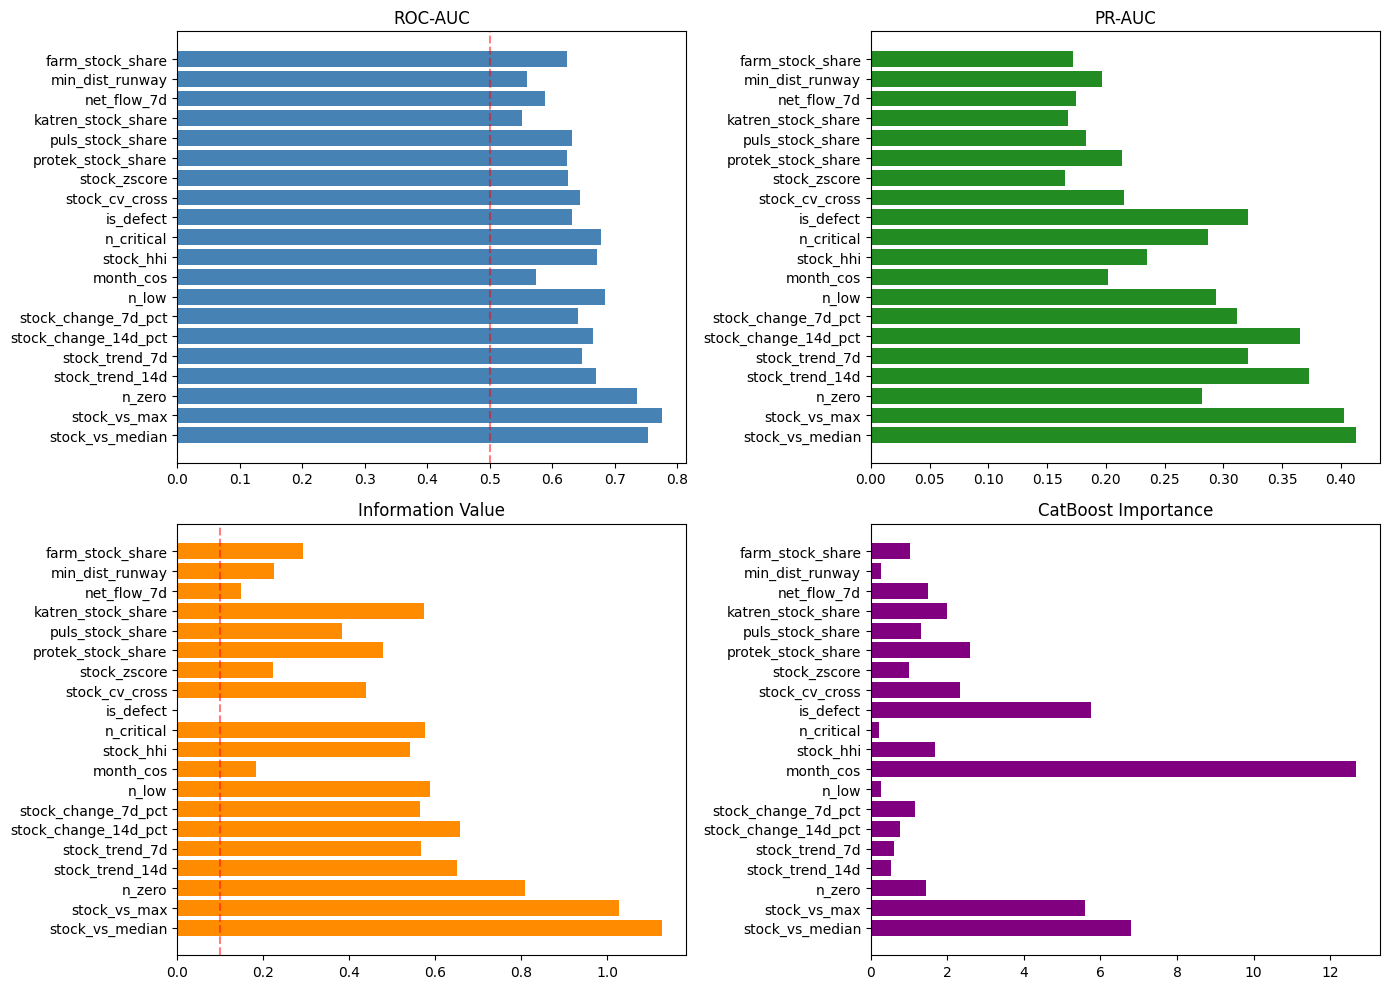

In [75]:
import matplotlib.pyplot as plt

def plot_feature_importance(summary, top_n=20):
    """Визуализация важности фичей"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    top = summary.head(top_n)
    
    # ROC-AUC
    axes[0, 0].barh(top.index, top['roc_auc'], color='steelblue')
    axes[0, 0].set_title('ROC-AUC')
    axes[0, 0].axvline(0.5, color='red', linestyle='--', alpha=0.5)
    
    # PR-AUC
    axes[0, 1].barh(top.index, top['pr_auc'], color='forestgreen')
    axes[0, 1].set_title('PR-AUC')
    
    # IV
    axes[1, 0].barh(top.index, top['iv'], color='darkorange')
    axes[1, 0].set_title('Information Value')
    axes[1, 0].axvline(0.1, color='red', linestyle='--', alpha=0.5, label='strong')
    
    # CatBoost
    axes[1, 1].barh(top.index, top['catboost_importance'], color='purple')
    axes[1, 1].set_title('CatBoost Importance')
    
    plt.tight_layout()
    plt.show()

plot_feature_importance(summary)

In [76]:
from sklearn.model_selection import train_test_split

mask = final_df['target'].notna()

# ИСПРАВЛЕНИЕ: преобразуем best_features в список
if isinstance(best_features, pd.DataFrame):
    feature_list = best_features.index.tolist()
elif isinstance(best_features, pd.Series):
    feature_list = best_features.index.tolist()
elif isinstance(best_features, list):
    feature_list = best_features
else:
    feature_list = list(best_features)

# Проверка, что все фичи есть в датафрейме
missing_features = [f for f in feature_list if f not in final_df.columns]
if missing_features:
    print(f"⚠️ Отсутствуют {len(missing_features)} фичей:")
    print(missing_features[:10])
    # Убираем отсутствующие
    feature_list = [f for f in feature_list if f in final_df.columns]

print(f"📊 Используется {len(feature_list)} признаков")

# Теперь работает
X = final_df.loc[mask, feature_list].fillna(0).clip(-1e10, 1e10)
y = final_df.loc[mask, 'target']

print(f"✅ Строк: {len(X)}, NaN в y: {y.isna().sum()}")
print(f"   Размер X: {X.shape}")

📊 Используется 30 признаков
✅ Строк: 1483928, NaN в y: 0
   Размер X: (1483928, 30)


In [77]:


# Берем топ-50 лучших признаков
best_features = summary.head(50).index.tolist()

# Или если хотите больше/меньше:
best_features = summary.head(100).index.tolist()  # топ-100

In [78]:
# from catboost import CatBoostClassifier, Pool
# from sklearn.metrics import (
#     roc_auc_score,
#     average_precision_score,
#     classification_report,
#     precision_recall_curve
# )
# import pandas as pd
# import numpy as np

# # ================================================================
# # ПОДГОТОВКА ДАННЫХ (БЕЗ ПАДЕНИЯ ПО ПАМЯТИ)
# # ================================================================

# # Берём только реально нужные колонки
# cols_needed = ['date', 'target', 'code_kag'] + best_features

# # Фильтр по таргету БЕЗ copy()
# mask = final_df['target'].notna()
# df = final_df.loc[mask, cols_needed]

# # Приводим признаки в float32 + чистим NaN и экстремумы ОДИН РАЗ
# df[best_features] = (
#     df[best_features]
#         .astype('float32')
#         .fillna(0.0)
#         .clip(-1e10, 1e10)
# )

# # Дата должна быть datetime
# df['date'] = pd.to_datetime(df['date'])

# # Последний день
# last_date = df['date'].max()
# prev_date = df.loc[df['date'] < last_date, 'date'].max()

# print(f"📅 Последняя дата:      {last_date}")
# print(f"📅 Предпоследняя дата: {prev_date}")

# # Split
# train_mask = df['date'] < last_date
# test_mask  = df['date'] == last_date

# X_train = df.loc[train_mask, best_features]
# y_train = df.loc[train_mask, 'target'].astype(int)

# X_test  = df.loc[test_mask, best_features]
# y_test  = df.loc[test_mask, 'target'].astype(int)

# print(f"\n📊 Train: {len(X_train):,} строк | OOS: {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
# print(f"📊 Test:  {len(X_test):,} строк | OOS: {y_test.sum():,} ({y_test.mean()*100:.3f}%)")

# # ================================================================
# # ОБУЧЕНИЕ (через Pool — экономит память)
# # ================================================================

# train_pool = Pool(X_train, y_train)
# test_pool  = Pool(X_test, y_test)

# model = CatBoostClassifier(
#     iterations=1000,
#     depth=6,
#     learning_rate=0.05,
#     auto_class_weights='Balanced',
#     eval_metric='AUC',
#     early_stopping_rounds=50,
#     verbose=100,
#     random_state=42
# )

# model.fit(
#     train_pool,
#     eval_set=test_pool
# )

# # ================================================================
# # ПРЕДСКАЗАНИЕ НА ПОСЛЕДНИЙ ДЕНЬ
# # ================================================================

# y_proba = model.predict_proba(X_test)[:, 1]

# print(f"\n{'='*60}")
# print(f"{'РЕЗУЛЬТАТЫ НА ПОСЛЕДНИЙ ДЕНЬ':^60}")
# print(f"{'='*60}")
# print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
# print(f"PR-AUC:  {average_precision_score(y_test, y_proba):.4f}")

# # ================================================================
# # АНАЛИЗ ПРЕДСКАЗАНИЙ
# # ================================================================

# results = df.loc[
#     test_mask,
#     ['code_kag', 'date', 'target'] + best_features[:5]
# ].copy()

# results['oos_probability'] = y_proba
# results = results.sort_values('oos_probability', ascending=False)

# print(f"\n{'='*60}")
# print(f"{'ТОП-20 SKU С НАИБОЛЬШИМ РИСКОМ OOS':^60}")
# print(f"{'='*60}")
# print(
#     results[['code_kag', 'target', 'oos_probability']]
#     .head(20)
#     .to_string(index=False)
# )

# # ================================================================
# # ОПТИМАЛЬНЫЙ ПОРОГ (ПО F1)
# # ================================================================

# precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# f1 = 2 * precision * recall / (precision + recall + 1e-12)
# best_idx = np.argmax(f1)

# best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

# print(f"\n{'='*60}")
# print(f"{'ОПТИМАЛЬНЫЙ ПОРОГ':^60}")
# print(f"{'='*60}")
# print(f"Порог:     {best_threshold:.4f}")
# print(f"Precision: {precision[best_idx]:.4f}")
# print(f"Recall:    {recall[best_idx]:.4f}")
# print(f"F1:        {f1[best_idx]:.4f}")

# # ================================================================
# # CLASSIFICATION REPORT
# # ================================================================

# y_pred = (y_proba >= best_threshold).astype(int)

# print(f"\n{'='*60}")
# print(f"{'CLASSIFICATION REPORT':^60}")
# print(f"{'='*60}")
# print(classification_report(y_test, y_pred, target_names=['Норма', 'OOS']))

# # ================================================================
# # ИТОГ: СКОЛЬКО OOS ПОЙМАЛИ
# # ================================================================

# true_oos = int(y_test.sum())
# predicted_oos = int(y_pred.sum())
# caught_oos = int(((y_pred == 1) & (y_test == 1)).sum())

# recall_real = caught_oos / true_oos * 100 if true_oos > 0 else 0

# print(f"\n{'='*60}")
# print(f"{'ИТОГ':^60}")
# print(f"{'='*60}")
# print(f"Реальных OOS:      {true_oos:,}")
# print(f"Предсказано OOS:   {predicted_oos:,}")
# print(f"Правильно поймали: {caught_oos:,} ({recall_real:.1f}% recall)")


In [79]:
# # Анализ разных порогов
# print("="*70)
# print(f"{'АНАЛИЗ ПОРОГОВ':^70}")
# print("="*70)
# print(f"{'Порог':<10} {'Precision':<12} {'Recall':<12} {'F1':<10} {'Алертов':<10} {'Поймано OOS'}")
# print("-"*70)

# for threshold in [0.9, 0.8, 0.7, 0.5, 0.3, 0.2, 0.1, 0.05]:
#     y_pred_t = (y_proba >= threshold).astype(int)
    
#     tp = ((y_pred_t == 1) & (y_test == 1)).sum()  # поймали OOS
#     fp = ((y_pred_t == 1) & (y_test == 0)).sum()  # ложные алерты
#     fn = ((y_pred_t == 0) & (y_test == 1)).sum()  # пропустили OOS
    
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#     f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
#     total_alerts = y_pred_t.sum()
    
#     print(f"{threshold:<10.2f} {precision:<12.3f} {recall:<12.3f} {f1:<10.3f} {total_alerts:<10} {tp}/{int(y_test.sum())}")

# # Рекомендуемый порог для бизнеса (высокий recall)
# business_threshold = 0.3
# y_pred_business = (y_proba >= business_threshold).astype(int)

# print(f"\n{'='*70}")
# print(f"{'РЕКОМЕНДАЦИЯ ДЛЯ БИЗНЕСА (порог {})'.format(business_threshold):^70}")
# print(f"{'='*70}")

# tp = ((y_pred_business == 1) & (y_test == 1)).sum()
# total_alerts = y_pred_business.sum()

# print(f"Поймано OOS: {tp} из {int(y_test.sum())} ({tp/y_test.sum()*100:.0f}%)")
# print(f"Всего алертов: {total_alerts}")
# print(f"Ложных алертов: {total_alerts - tp}")

In [80]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, precision_score, recall_score
)


def train_and_evaluate_full(
    df,
    features,
    date_col='date',
    target_col='target',
    test_days=30,
    gap_days=14,
    model_name="Model",
    cost_fn=1000,  # Стоимость пропуска OOS
    cost_fp=10,    # Стоимость ложной проверки
):
    """
    Полное обучение с анализом threshold и бизнес-оптимизацией.
    """
    
    print(f"\n{'='*70}")
    print(f"🚀 {model_name}")
    print(f"{'='*70}")
    
    # Фильтруем и сортируем
    valid_mask = df[target_col].notna()
    df_sorted = df[valid_mask].sort_values(by=[date_col]).copy()
    
    # Проверяем features
    available_features = [f for f in features if f in df_sorted.columns]
    print(f"📊 Данных: {len(df_sorted):,} строк")
    print(f"🎯 Фичей: {len(available_features)}")
    
    # Temporal split с gap
    max_date = df_sorted[date_col].max()
    test_start = max_date - pd.Timedelta(days=test_days)
    train_end = test_start - pd.Timedelta(days=gap_days)
    
    train_mask = df_sorted[date_col] <= train_end
    test_mask = df_sorted[date_col] > test_start
    
    X_train = df_sorted.loc[train_mask, available_features].fillna(-999)
    y_train = df_sorted.loc[train_mask, target_col]
    X_test = df_sorted.loc[test_mask, available_features].fillna(-999)
    y_test = df_sorted.loc[test_mask, target_col]
    
    print(f"\n📅 Split:")
    print(f"   Train: {len(X_train):,} rows (до {train_end.date()})")
    print(f"   Gap:   {gap_days} дней")
    print(f"   Test:  {len(X_test):,} rows (после {test_start.date()})")
    print(f"   Train target rate: {y_train.mean():.2%}")
    print(f"   Test target rate:  {y_test.mean():.2%}")
    
    # LightGBM
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'min_child_samples': 50,
        'is_unbalance': True,
        'verbose': -1,
        'seed': 42,
    }
    
    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)
    
    model = lgb.train(
        params,
        train_data,
        num_boost_round=500,
        valid_sets=[valid_data],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    
    y_proba = model.predict(X_test)
    
    # Базовые метрики
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    
    print(f"\n📈 БАЗОВЫЕ МЕТРИКИ:")
    print(f"   ROC-AUC: {roc_auc:.4f}")
    print(f"   PR-AUC:  {pr_auc:.4f}")
    print(f"   Baseline PR-AUC (random): {y_test.mean():.4f}")
    print(f"   Улучшение над baseline: {pr_auc / y_test.mean():.1f}x")
    
    # ================================================================
    # РАСШИРЕННЫЙ АНАЛИЗ ПО THRESHOLD
    # ================================================================
    print(f"\n{'='*70}")
    print(f"📊 АНАЛИЗ ПО THRESHOLD")
    print(f"{'='*70}")
    print(f"{'Thresh':<8} {'Prec':<8} {'Recall':<8} {'F1':<8} {'TP':<8} {'FP':<8} {'FN':<8} {'Cost':<12} {'FP/TP':<8}")
    print("-" * 85)
    
    results_by_thresh = []
    best_f1, best_f1_thresh = 0, 0.5
    best_cost, best_cost_thresh = float('inf'), 0.5
    
    # Расширенный диапазон threshold
    thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 
                  0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        # Бизнес-стоимость
        total_cost = fn * cost_fn + fp * cost_fp
        
        # Ratio FP/TP
        fp_tp_ratio = fp / tp if tp > 0 else float('inf')
        
        results_by_thresh.append({
            'threshold': thresh,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'TP': tp,
            'FP': fp,
            'TN': tn,
            'FN': fn,
            'cost': total_cost,
            'fp_tp_ratio': fp_tp_ratio
        })
        
        # Форматируем вывод
        cost_str = f"{total_cost:,.0f}"
        fp_tp_str = f"{fp_tp_ratio:.1f}" if fp_tp_ratio < 1000 else "inf"
        
        print(f"{thresh:<8.2f} {prec:<8.3f} {rec:<8.3f} {f1:<8.3f} {tp:<8} {fp:<8} {fn:<8} {cost_str:<12} {fp_tp_str:<8}")
        
        if f1 > best_f1:
            best_f1, best_f1_thresh = f1, thresh
        
        if total_cost < best_cost:
            best_cost, best_cost_thresh = total_cost, thresh
    
    results_df = pd.DataFrame(results_by_thresh)
    
    # ================================================================
    # ЛУЧШИЕ THRESHOLD ПО РАЗНЫМ КРИТЕРИЯМ
    # ================================================================
    print(f"\n{'='*70}")
    print(f"🏆 ЛУЧШИЕ THRESHOLD ПО КРИТЕРИЯМ")
    print(f"{'='*70}")
    
    # 1. По F1
    best_f1_row = results_df[results_df['threshold'] == best_f1_thresh].iloc[0]
    print(f"\n1️⃣  ЛУЧШИЙ ПО F1 (threshold={best_f1_thresh:.2f}):")
    print(f"    F1={best_f1_row['f1']:.4f}, Prec={best_f1_row['precision']:.2%}, Recall={best_f1_row['recall']:.2%}")
    print(f"    TP={best_f1_row['TP']:,}, FP={best_f1_row['FP']:,}, FN={best_f1_row['FN']:,}")
    print(f"    FP/TP ratio: {best_f1_row['fp_tp_ratio']:.1f}")
    
    # 2. По бизнес-стоимости
    best_cost_row = results_df[results_df['threshold'] == best_cost_thresh].iloc[0]
    print(f"\n2️⃣  ЛУЧШИЙ ПО СТОИМОСТИ (threshold={best_cost_thresh:.2f}):")
    print(f"    Cost={best_cost_row['cost']:,.0f} руб (FN×{cost_fn} + FP×{cost_fp})")
    print(f"    Prec={best_cost_row['precision']:.2%}, Recall={best_cost_row['recall']:.2%}")
    print(f"    TP={best_cost_row['TP']:,}, FP={best_cost_row['FP']:,}, FN={best_cost_row['FN']:,}")
    
    # 3. По минимальному FP/TP при recall > 50%
    high_recall_df = results_df[results_df['recall'] >= 0.5]
    if len(high_recall_df) > 0:
        best_ratio_row = high_recall_df.loc[high_recall_df['fp_tp_ratio'].idxmin()]
        print(f"\n3️⃣  ЛУЧШИЙ FP/TP ПРИ RECALL≥50% (threshold={best_ratio_row['threshold']:.2f}):")
        print(f"    FP/TP ratio: {best_ratio_row['fp_tp_ratio']:.1f}")
        print(f"    Prec={best_ratio_row['precision']:.2%}, Recall={best_ratio_row['recall']:.2%}")
        print(f"    TP={best_ratio_row['TP']:,}, FP={best_ratio_row['FP']:,}, FN={best_ratio_row['FN']:,}")
    
    # 4. Precision ≥ 10%
    high_prec_df = results_df[results_df['precision'] >= 0.10]
    if len(high_prec_df) > 0:
        best_prec_row = high_prec_df.loc[high_prec_df['recall'].idxmax()]
        print(f"\n4️⃣  ЛУЧШИЙ RECALL ПРИ PRECISION≥10% (threshold={best_prec_row['threshold']:.2f}):")
        print(f"    Prec={best_prec_row['precision']:.2%}, Recall={best_prec_row['recall']:.2%}")
        print(f"    TP={best_prec_row['TP']:,}, FP={best_prec_row['FP']:,}, FN={best_prec_row['FN']:,}")
    else:
        print(f"\n4️⃣  PRECISION≥10% недостижим на данных")
    
    # ================================================================
    # ДВУХСТУПЕНЧАТЫЙ ПОДХОД
    # ================================================================
    print(f"\n{'='*70}")
    print(f"🔄 ДВУХСТУПЕНЧАТЫЙ ПОДХОД")
    print(f"{'='*70}")
    
    # Ступень 1: Грубый фильтр (высокий recall)
    coarse_thresh = 0.15
    coarse_mask = y_proba >= coarse_thresh
    coarse_row = results_df[results_df['threshold'] == coarse_thresh].iloc[0]
    
    print(f"\n📌 Ступень 1: Грубый фильтр (threshold={coarse_thresh})")
    print(f"   Отбираем: {coarse_mask.sum():,} позиций ({coarse_mask.mean():.1%} от теста)")
    print(f"   Recall: {coarse_row['recall']:.1%} (ловим {coarse_row['TP']:,} из {int(coarse_row['TP'] + coarse_row['FN']):,} OOS)")
    
    # Ступень 2: Дополнительные правила
    # Получаем данные для анализа
    test_data = X_test.copy()
    test_data['y_true'] = y_test.values
    test_data['y_proba'] = y_proba
    test_data['coarse_filter'] = coarse_mask
    
    # Примеры дополнительных правил
    rules_analysis = []
    
    # Правило: gk_stock = 0 (если есть)
    if 'gk_is_zero' in test_data.columns:
        rule_mask = coarse_mask & (test_data['gk_is_zero'] == 1)
        if rule_mask.sum() > 0:
            rule_tp = (test_data.loc[rule_mask, 'y_true'] == 1).sum()
            rule_fp = (test_data.loc[rule_mask, 'y_true'] == 0).sum()
            rule_prec = rule_tp / (rule_tp + rule_fp) if (rule_tp + rule_fp) > 0 else 0
            rules_analysis.append({
                'rule': 'gk_is_zero=1',
                'count': rule_mask.sum(),
                'TP': rule_tp,
                'FP': rule_fp,
                'precision': rule_prec
            })
    
    # Правило: n_zero >= 2
    if 'n_zero' in test_data.columns:
        rule_mask = coarse_mask & (test_data['n_zero'] >= 2)
        if rule_mask.sum() > 0:
            rule_tp = (test_data.loc[rule_mask, 'y_true'] == 1).sum()
            rule_fp = (test_data.loc[rule_mask, 'y_true'] == 0).sum()
            rule_prec = rule_tp / (rule_tp + rule_fp) if (rule_tp + rule_fp) > 0 else 0
            rules_analysis.append({
                'rule': 'n_zero>=2',
                'count': rule_mask.sum(),
                'TP': rule_tp,
                'FP': rule_fp,
                'precision': rule_prec
            })
    
    # Правило: days_of_stock < 7
    if 'days_of_stock' in test_data.columns:
        rule_mask = coarse_mask & (test_data['days_of_stock'] < 7)
        if rule_mask.sum() > 0:
            rule_tp = (test_data.loc[rule_mask, 'y_true'] == 1).sum()
            rule_fp = (test_data.loc[rule_mask, 'y_true'] == 0).sum()
            rule_prec = rule_tp / (rule_tp + rule_fp) if (rule_tp + rule_fp) > 0 else 0
            rules_analysis.append({
                'rule': 'days_of_stock<7',
                'count': rule_mask.sum(),
                'TP': rule_tp,
                'FP': rule_fp,
                'precision': rule_prec
            })
    
    # Правило: stock_vs_median < 0.3
    if 'stock_vs_median' in test_data.columns:
        rule_mask = coarse_mask & (test_data['stock_vs_median'] < 0.3)
        if rule_mask.sum() > 0:
            rule_tp = (test_data.loc[rule_mask, 'y_true'] == 1).sum()
            rule_fp = (test_data.loc[rule_mask, 'y_true'] == 0).sum()
            rule_prec = rule_tp / (rule_tp + rule_fp) if (rule_tp + rule_fp) > 0 else 0
            rules_analysis.append({
                'rule': 'stock_vs_median<0.3',
                'count': rule_mask.sum(),
                'TP': rule_tp,
                'FP': rule_fp,
                'precision': rule_prec
            })
    
    # Комбинация правил
    combo_mask = coarse_mask.copy()
    if 'n_zero' in test_data.columns:
        combo_mask = combo_mask & (test_data['n_zero'] >= 1)
    if 'stock_vs_median' in test_data.columns:
        combo_mask = combo_mask & (test_data['stock_vs_median'] < 0.5)
    
    if combo_mask.sum() > 0:
        combo_tp = (test_data.loc[combo_mask, 'y_true'] == 1).sum()
        combo_fp = (test_data.loc[combo_mask, 'y_true'] == 0).sum()
        combo_prec = combo_tp / (combo_tp + combo_fp) if (combo_tp + combo_fp) > 0 else 0
        rules_analysis.append({
            'rule': 'n_zero>=1 & stock_vs_median<0.5',
            'count': combo_mask.sum(),
            'TP': combo_tp,
            'FP': combo_fp,
            'precision': combo_prec
        })
    
    if rules_analysis:
        print(f"\n📌 Ступень 2: Дополнительные фильтры (после грубого отбора)")
        rules_df = pd.DataFrame(rules_analysis).sort_values('precision', ascending=False)
        print(rules_df.to_string(index=False))
    
    # ================================================================
    # TOP FEATURES
    # ================================================================
    importance = pd.DataFrame({
        'feature': available_features,
        'importance': model.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    
    print(f"\n{'='*70}")
    print(f"📈 TOP-15 ФИЧЕЙ")
    print(f"{'='*70}")
    print(importance.head(15).to_string(index=False))
    
    return {
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'best_f1': best_f1,
        'best_f1_threshold': best_f1_thresh,
        'best_cost': best_cost,
        'best_cost_threshold': best_cost_thresh,
        'model': model,
        'importance': importance,
        'results_by_thresh': results_df,
        'y_test': y_test,
        'y_proba': y_proba,
        'X_test': X_test
    }


# ================================================================
# ЗАПУСК
# ================================================================

print("🔥" * 35)
print("ПОЛНЫЙ АНАЛИЗ МОДЕЛИ")
print("🔥" * 35)

# Укажи свои реальные стоимости ошибок
COST_FN = 1000  # Стоимость пропуска дефицита (руб)
COST_FP = 10    # Стоимость лишней проверки (руб)

print(f"\n💰 Бизнес-параметры:")
print(f"   Стоимость пропуска OOS (FN): {COST_FN:,} руб")
print(f"   Стоимость ложной проверки (FP): {COST_FP:,} руб")
print(f"   Ratio: 1 пропуск = {COST_FN // COST_FP} ложных проверок")

# Модель со всеми фичами
results = train_and_evaluate_full(
    final_df,
    features=feature_cols,
    test_days=30,
    gap_days=14,
    model_name="🟢 ПОЛНАЯ МОДЕЛЬ",
    cost_fn=COST_FN,
    cost_fp=COST_FP
)

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
ПОЛНЫЙ АНАЛИЗ МОДЕЛИ
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

💰 Бизнес-параметры:
   Стоимость пропуска OOS (FN): 1,000 руб
   Стоимость ложной проверки (FP): 10 руб
   Ratio: 1 пропуск = 100 ложных проверок

🚀 🟢 ПОЛНАЯ МОДЕЛЬ
📊 Данных: 1,483,928 строк
🎯 Фичей: 155

📅 Split:
   Train: 1,332,388 rows (до 2025-12-10)
   Gap:   14 дней
   Test:  90,440 rows (после 2025-12-24)
   Train target rate: 12.08%
   Test target rate:  13.04%
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[75]	valid_0's auc: 0.919962

📈 БАЗОВЫЕ МЕТРИКИ:
   ROC-AUC: 0.9200
   PR-AUC:  0.7153
   Baseline PR-AUC (random): 0.1304
   Улучшение над baseline: 5.5x

📊 АНАЛИЗ ПО THRESHOLD
Thresh   Prec     Recall   F1       TP       FP       FN       Cost         FP/TP   
-------------------------------------------------------------------------------------
0.05     0.149    0.999    0.260    11781    67037    16       686,370      5.7     
0.10

light gbm

In [81]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve
)
import gc
import warnings
warnings.filterwarnings('ignore')


def train_optimized_for_precision(
    df,
    features,
    date_col='date',
    target_col='target',
    test_days=30,
    gap_days=14,
    model_name="Model",
    min_precision_target=0.10,
    daily_check_capacity=500,
):
    """
    Модель оптимизированная под уменьшение FP.
    Версия без Focal Loss (проще и стабильнее).
    """
    
    print(f"\n{'='*70}")
    print(f"🚀 {model_name}")
    print(f"{'='*70}")
    
    # ================================================================
    # ПОДГОТОВКА ДАННЫХ (оптимизировано по памяти)
    # ================================================================
    valid_mask = df[target_col].notna()
    available_features = [f for f in features if f in df.columns]
    
    print(f"📊 Данных: {valid_mask.sum():,} строк")
    print(f"🎯 Фичей: {len(available_features)}")
    
    # Temporal split — маски без копирования
    max_date = df.loc[valid_mask, date_col].max()
    test_start = max_date - pd.Timedelta(days=test_days)
    train_end = test_start - pd.Timedelta(days=gap_days)
    
    train_mask = valid_mask & (df[date_col] <= train_end)
    test_mask = valid_mask & (df[date_col] > test_start)
    
    print(f"\n📅 Split:")
    print(f"   Train: {train_mask.sum():,} rows (до {train_end.date()})")
    print(f"   Test:  {test_mask.sum():,} rows (после {test_start.date()})")
    
    # Извлекаем данные с оптимизацией памяти
    X_train = df.loc[train_mask, available_features].fillna(-999).astype(np.float32)
    y_train = df.loc[train_mask, target_col].astype(np.float32)
    X_test = df.loc[test_mask, available_features].fillna(-999).astype(np.float32)
    y_test = df.loc[test_mask, target_col].astype(np.float32)
    
    gc.collect()
    
    # Статистика дисбаланса
    pos_rate = y_train.mean()
    imbalance_ratio = (1 - pos_rate) / pos_rate
    
    print(f"\n⚖️  Дисбаланс:")
    print(f"   Positive rate: {pos_rate:.2%}")
    print(f"   Imbalance ratio: {imbalance_ratio:.1f}:1")
    
    # ================================================================
    # МОДЕЛЬ 1: BASELINE
    # ================================================================
    print(f"\n{'='*70}")
    print(f"📊 МОДЕЛЬ 1: BASELINE")
    print(f"{'='*70}")
    
    params_baseline = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'min_child_samples': 50,
        'is_unbalance': True,
        'verbose': -1,
        'seed': 42,
    }
    
    train_data = lgb.Dataset(X_train, label=y_train, free_raw_data=True)
    valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data, free_raw_data=True)
    
    model_baseline = lgb.train(
        params_baseline,
        train_data,
        num_boost_round=500,
        valid_sets=[valid_data],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    
    y_proba_baseline = model_baseline.predict(X_test)
    pr_auc_baseline = average_precision_score(y_test, y_proba_baseline)
    roc_auc_baseline = roc_auc_score(y_test, y_proba_baseline)
    print(f"   ROC-AUC: {roc_auc_baseline:.4f}")
    print(f"   PR-AUC: {pr_auc_baseline:.4f}")
    
    # ================================================================
    # МОДЕЛЬ 2: ОПТИМИЗИРОВАННАЯ ПОД PRECISION
    # ================================================================
    print(f"\n{'='*70}")
    print(f"📊 МОДЕЛЬ 2: ОПТИМИЗИРОВАННАЯ (консервативная)")
    print(f"{'='*70}")
    
    # Консервативные параметры: меньше FP
    scale_weight = imbalance_ratio * 0.5
    
    params_optimized = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'num_leaves': 15,
        'learning_rate': 0.01,
        'feature_fraction': 0.7,
        'bagging_fraction': 0.7,
        'bagging_freq': 5,
        'min_child_samples': 100,
        'min_child_weight': 10,
        'scale_pos_weight': scale_weight,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
        'verbose': -1,
        'seed': 42,
    }
    
    print(f"   scale_pos_weight: {scale_weight:.1f}")
    
    # Пересоздаём Dataset (предыдущий мог быть освобождён)
    train_data2 = lgb.Dataset(X_train, label=y_train, free_raw_data=True)
    valid_data2 = lgb.Dataset(X_test, label=y_test, reference=train_data2, free_raw_data=True)
    
    model_optimized = lgb.train(
        params_optimized,
        train_data2,
        num_boost_round=10000,
        valid_sets=[valid_data2],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    
    y_proba_optimized = model_optimized.predict(X_test)
    pr_auc_optimized = average_precision_score(y_test, y_proba_optimized)
    roc_auc_optimized = roc_auc_score(y_test, y_proba_optimized)
    print(f"   ROC-AUC: {roc_auc_optimized:.4f}")
    print(f"   PR-AUC: {pr_auc_optimized:.4f}")
    
    # Освобождаем память
    del X_train, train_data, train_data2, valid_data, valid_data2
    gc.collect()
    
    # ================================================================
    # ВЫБОР ЛУЧШЕЙ МОДЕЛИ
    # ================================================================
    if pr_auc_optimized >= pr_auc_baseline:
        best_model = model_optimized
        y_proba = y_proba_optimized
        best_pr_auc = pr_auc_optimized
        best_name = "optimized"
    else:
        best_model = model_baseline
        y_proba = y_proba_baseline
        best_pr_auc = pr_auc_baseline
        best_name = "baseline"
    
    print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_name} (PR-AUC={best_pr_auc:.4f})")
    
    # ================================================================
    # RECALL@K АНАЛИЗ
    # ================================================================
    print(f"\n{'='*70}")
    print(f"📊 RECALL@K АНАЛИЗ")
    print(f"{'='*70}")
    
    total_oos = y_test.sum()
    total_samples = len(y_test)
    
    sorted_indices = np.argsort(y_proba)[::-1]
    y_true_sorted = y_test.values[sorted_indices]
    
    print(f"   Всего OOS: {total_oos:.0f}")
    print(f"\n{'Top-K':<10} {'TP':<10} {'FP':<10} {'Recall':<10} {'Precision':<12}")
    print("-" * 55)
    
    recall_at_k_results = []
    
    for k in [100, 200, 300, 500, 750, 1000, 1500, 2000, 3000, 5000, 10000]:
        if k > len(y_test):
            continue
        
        tp = y_true_sorted[:k].sum()
        fp = k - tp
        recall = tp / total_oos if total_oos > 0 else 0
        precision = tp / k
        
        print(f"{k:<10} {tp:<10.0f} {fp:<10.0f} {recall:<10.1%} {precision:<12.1%}")
        
        recall_at_k_results.append({
            'k': k, 'tp': tp, 'fp': fp,
            'recall': recall, 'precision': precision
        })
    
    recall_at_k_df = pd.DataFrame(recall_at_k_results)
    
    # ================================================================
    # ОПТИМАЛЬНЫЙ K
    # ================================================================
    print(f"\n{'='*70}")
    print(f"🎯 ОПТИМАЛЬНЫЙ K ДЛЯ PRECISION ≥ {min_precision_target:.0%}")
    print(f"{'='*70}")
    
    valid_k = recall_at_k_df[recall_at_k_df['precision'] >= min_precision_target]
    
    if len(valid_k) > 0:
        best_k_row = valid_k.loc[valid_k['recall'].idxmax()]
        print(f"   K = {best_k_row['k']:.0f}")
        print(f"   Recall: {best_k_row['recall']:.1%} (ловим {best_k_row['tp']:.0f} OOS)")
        print(f"   Precision: {best_k_row['precision']:.1%}")
        print(f"   FP: {best_k_row['fp']:.0f}")
    else:
        best_k_row = recall_at_k_df.loc[recall_at_k_df['precision'].idxmax()]
        print(f"   ⚠️ Precision {min_precision_target:.0%} недостижим")
        print(f"   Лучший: K={best_k_row['k']:.0f}, Prec={best_k_row['precision']:.1%}")
    
    # ================================================================
    # РЕКОМЕНДАЦИЯ
    # ================================================================
    print(f"\n{'='*70}")
    print(f"💼 РЕКОМЕНДАЦИЯ ДЛЯ БИЗНЕСА")
    print(f"{'='*70}")
    
    # Ближайший K к capacity
    k_values = recall_at_k_df['k'].tolist()
    closest_k = min(k_values, key=lambda x: abs(x - daily_check_capacity))
    capacity_row = recall_at_k_df[recall_at_k_df['k'] == closest_k].iloc[0]
    
    print(f"\n   📌 При проверке {closest_k} позиций в день:")
    print(f"      • TP (поймаем OOS): {capacity_row['tp']:.0f} из {total_oos:.0f}")
    print(f"      • FP (ложные): {capacity_row['fp']:.0f}")
    print(f"      • Recall: {capacity_row['recall']:.1%}")
    print(f"      • Precision: {capacity_row['precision']:.1%}")
    
    # ================================================================
    # THRESHOLD АНАЛИЗ
    # ================================================================
    print(f"\n{'='*70}")
    print(f"📊 THRESHOLD АНАЛИЗ")
    print(f"{'='*70}")
    
    print(f"\n{'Thresh':<10} {'Prec':<10} {'Recall':<10} {'TP':<8} {'FP':<10} {'FP/TP':<8}")
    print("-" * 58)
    
    for thresh in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        y_pred = (y_proba >= thresh).astype(int)
        if y_pred.sum() == 0:
            continue
        
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        fp_tp = fp / tp if tp > 0 else float('inf')
        
        print(f"{thresh:<10.2f} {prec:<10.1%} {rec:<10.1%} {tp:<8} {fp:<10} {fp_tp:<8.1f}")
    
    # ================================================================
    # FEATURE IMPORTANCE
    # ================================================================
    importance = pd.DataFrame({
        'feature': available_features,
        'importance': best_model.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    
    print(f"\n{'='*70}")
    print(f"📈 TOP-15 ФИЧЕЙ")
    print(f"{'='*70}")
    print(importance.head(15).to_string(index=False))
    
    return {
        'model': best_model,
        'model_name': best_name,
        'y_proba': y_proba,
        'y_test': y_test,
        'X_test': X_test,
        'pr_auc': best_pr_auc,
        'recall_at_k': recall_at_k_df,
        'importance': importance,
    }


# ================================================================
# ЗАПУСК
# ================================================================

print("🔥" * 35)
print("МОДЕЛЬ ОПТИМИЗИРОВАННАЯ ПОД PRECISION")
print("🔥" * 35)

results = train_optimized_for_precision(
    final_df,
    features=feature_cols,
    test_days=30,
    gap_days=14,
    model_name="🎯 PRECISION-OPTIMIZED MODEL",
    min_precision_target=0.10,
    daily_check_capacity=500,
)

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
МОДЕЛЬ ОПТИМИЗИРОВАННАЯ ПОД PRECISION
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

🚀 🎯 PRECISION-OPTIMIZED MODEL
📊 Данных: 1,483,928 строк
🎯 Фичей: 155

📅 Split:
   Train: 1,332,388 rows (до 2025-12-10)
   Test:  90,440 rows (после 2025-12-24)

⚖️  Дисбаланс:
   Positive rate: 12.08%
   Imbalance ratio: 7.3:1

📊 МОДЕЛЬ 1: BASELINE
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[64]	valid_0's auc: 0.920131
   ROC-AUC: 0.9201
   PR-AUC: 0.7151

📊 МОДЕЛЬ 2: ОПТИМИЗИРОВАННАЯ (консервативная)
   scale_pos_weight: 3.6
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[390]	valid_0's average_precision: 0.716161
   ROC-AUC: 0.9194
   PR-AUC: 0.7162

🏆 ЛУЧШАЯ МОДЕЛЬ: optimized (PR-AUC=0.7162)

📊 RECALL@K АНАЛИЗ
   Всего OOS: 11797

Top-K      TP         FP         Recall     Precision   
-------------------------------------------------------
100        98         2        

In [82]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve
)
import optuna
from optuna.samplers import TPESampler
import gc
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


def train_catboost_with_optuna(
    df,
    features,
    date_col='date',
    target_col='target',
    test_days=30,
    gap_days=14,
    model_name="Model",
    min_precision_target=0.10,
    daily_check_capacity=500,
    cat_features=None,
    n_optuna_trials=30,
    # Новые параметры для сохранения
    save_model=True,
    model_dir="models",
    model_filename=None,  # Если None — автогенерация имени
):
    """
    CatBoost с подбором гиперпараметров через Optuna.
    Оптимизация по PR-AUC.
    
    Параметры сохранения:
    - save_model: True/False — сохранять ли модель
    - model_dir: папка для сохранения
    - model_filename: имя файла (без расширения)
    """
    
    print(f"\n{'='*70}")
    print(f"🚀 {model_name}")
    print(f"{'='*70}")
    
    # ================================================================
    # ПОДГОТОВКА ДАННЫХ
    # ================================================================
    valid_mask = df[target_col].notna()
    available_features = [f for f in features if f in df.columns]
    
    print(f"📊 Данных: {valid_mask.sum():,} строк")
    print(f"🎯 Фичей: {len(available_features)}")
    
    # Temporal split
    max_date = df.loc[valid_mask, date_col].max()
    test_start = max_date - pd.Timedelta(days=test_days)
    train_end = test_start - pd.Timedelta(days=gap_days)
    
    train_mask = valid_mask & (df[date_col] <= train_end)
    test_mask = valid_mask & (df[date_col] > test_start)
    
    print(f"\n📅 Split:")
    print(f"   Train: {train_mask.sum():,} rows (до {train_end.date()})")
    print(f"   Test:  {test_mask.sum():,} rows (после {test_start.date()})")
    
    # Данные для CatBoost
    X_train = df.loc[train_mask, available_features].copy()
    y_train = df.loc[train_mask, target_col].values
    X_test = df.loc[test_mask, available_features].copy()
    y_test = df.loc[test_mask, target_col].values
    
    # Категориальные фичи
    if cat_features is None:
        cat_features_detected = [
            col for col in available_features
            if X_train[col].dtype == 'object' or X_train[col].dtype.name == 'category'
        ]
    else:
        cat_features_detected = [f for f in cat_features if f in available_features]
    
    if cat_features_detected:
        print(f"   Категориальных фичей: {len(cat_features_detected)}")
    
    # Статистика дисбаланса
    pos_rate = y_train.mean()
    imbalance_ratio = (1 - pos_rate) / pos_rate
    
    print(f"\n⚖️  Дисбаланс:")
    print(f"   Positive rate: {pos_rate:.2%}")
    print(f"   Imbalance ratio: {imbalance_ratio:.1f}:1")
    
    # Pool для CatBoost
    train_pool = Pool(
        data=X_train,
        label=y_train,
        cat_features=cat_features_detected if cat_features_detected else None
    )
    test_pool = Pool(
        data=X_test,
        label=y_test,
        cat_features=cat_features_detected if cat_features_detected else None
    )
    
    gc.collect()
    
    # ================================================================
    # МОДЕЛЬ 1: CatBoost BASELINE
    # ================================================================
    print(f"\n{'='*70}")
    print(f"📊 МОДЕЛЬ 1: CatBoost BASELINE")
    print(f"{'='*70}")
    
    model_baseline = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        auto_class_weights='Balanced',
        eval_metric='AUC',
        early_stopping_rounds=50,
        verbose=100,
        random_seed=42,
        task_type='CPU',
    )
    
    model_baseline.fit(
        train_pool,
        eval_set=test_pool,
        use_best_model=True,
    )
    
    y_proba_baseline = model_baseline.predict_proba(test_pool)[:, 1]
    pr_auc_baseline = average_precision_score(y_test, y_proba_baseline)
    roc_auc_baseline = roc_auc_score(y_test, y_proba_baseline)
    
    print(f"\n   ROC-AUC: {roc_auc_baseline:.4f}")
    print(f"   PR-AUC: {pr_auc_baseline:.4f}")
    
    # ================================================================
    # МОДЕЛЬ 2: CatBoost + OPTUNA
    # ================================================================
    print(f"\n{'='*70}")
    print(f"📊 МОДЕЛЬ 2: CatBoost + OPTUNA ({n_optuna_trials} trials)")
    print(f"{'='*70}")
    
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 200, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, imbalance_ratio),
            'eval_metric': 'AUC',
            'early_stopping_rounds': 50,
            'verbose': 0,
            'random_seed': 42,
            'task_type': 'CPU',
        }
        
        model = CatBoostClassifier(**params)
        model.fit(train_pool, eval_set=test_pool, use_best_model=True)
        y_proba = model.predict_proba(test_pool)[:, 1]
        
        return average_precision_score(y_test, y_proba)
    
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_optuna_trials, show_progress_bar=True)
    
    print(f"\n   Лучший PR-AUC в Optuna: {study.best_value:.4f}")
    print(f"   Лучшие параметры:")
    for key, value in study.best_params.items():
        if isinstance(value, float):
            print(f"      {key}: {value:.4f}")
        else:
            print(f"      {key}: {value}")
    
    # Финальная модель
    best_params = study.best_params.copy()
    best_params['eval_metric'] = 'AUC'
    best_params['early_stopping_rounds'] = 50
    best_params['verbose'] = 100
    best_params['random_seed'] = 42
    best_params['task_type'] = 'CPU'
    
    model_optuna = CatBoostClassifier(**best_params)
    model_optuna.fit(train_pool, eval_set=test_pool, use_best_model=True)
    
    y_proba_optuna = model_optuna.predict_proba(test_pool)[:, 1]
    pr_auc_optuna = average_precision_score(y_test, y_proba_optuna)
    roc_auc_optuna = roc_auc_score(y_test, y_proba_optuna)
    
    print(f"\n   ROC-AUC: {roc_auc_optuna:.4f}")
    print(f"   PR-AUC: {pr_auc_optuna:.4f}")
    
    # Освобождаем память
    del X_train, train_pool
    gc.collect()
    
    # ================================================================
    # ВЫБОР ЛУЧШЕЙ МОДЕЛИ
    # ================================================================
    if pr_auc_optuna >= pr_auc_baseline:
        best_model = model_optuna
        y_proba = y_proba_optuna
        best_pr_auc = pr_auc_optuna
        best_roc_auc = roc_auc_optuna
        best_name = "CatBoost+Optuna"
        best_params_final = best_params
    else:
        best_model = model_baseline
        y_proba = y_proba_baseline
        best_pr_auc = pr_auc_baseline
        best_roc_auc = roc_auc_baseline
        best_name = "CatBoost Baseline"
        best_params_final = {
            'iterations': 500, 'learning_rate': 0.05, 'depth': 6,
            'auto_class_weights': 'Balanced'
        }
    
    print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_name}")
    print(f"   ROC-AUC: {best_roc_auc:.4f}")
    print(f"   PR-AUC: {best_pr_auc:.4f}")
    
    # ================================================================
    # RECALL@K АНАЛИЗ
    # ================================================================
    print(f"\n{'='*70}")
    print(f"📊 RECALL@K АНАЛИЗ")
    print(f"{'='*70}")
    
    total_oos = y_test.sum()
    sorted_indices = np.argsort(y_proba)[::-1]
    y_true_sorted = y_test[sorted_indices]
    
    print(f"   Всего OOS: {total_oos:.0f}")
    print(f"\n{'Top-K':<10} {'TP':<10} {'FP':<10} {'Recall':<10} {'Precision':<12}")
    print("-" * 55)
    
    recall_at_k_results = []
    for k in [100, 200, 300, 500, 750, 1000, 1500, 2000, 3000, 5000, 10000]:
        if k > len(y_test):
            continue
        tp = y_true_sorted[:k].sum()
        fp = k - tp
        recall = tp / total_oos if total_oos > 0 else 0
        precision = tp / k
        print(f"{k:<10} {tp:<10.0f} {fp:<10.0f} {recall:<10.1%} {precision:<12.1%}")
        recall_at_k_results.append({'k': k, 'tp': tp, 'fp': fp, 'recall': recall, 'precision': precision})
    
    recall_at_k_df = pd.DataFrame(recall_at_k_results)
    
    # ================================================================
    # ДЕТАЛЬНЫЙ THRESHOLD АНАЛИЗ (НОВОЕ!)
    # ================================================================
    print(f"\n{'='*70}")
    print(f"📊 ДЕТАЛЬНЫЙ THRESHOLD АНАЛИЗ (максимизация Precision)")
    print(f"{'='*70}")
    
    # Используем precision_recall_curve для точного анализа
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Собираем детальную таблицу
    threshold_results = []
    
    # Анализ с мелким шагом
    detailed_thresholds = np.arange(0.05, 0.96, 0.05).tolist()
    
    # Добавляем пороги для конкретных уровней precision
    target_precisions = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    
    print(f"\n{'Thresh':<8} {'Prec':<8} {'Recall':<8} {'F1':<8} {'TP':<7} {'FP':<7} {'FN':<7} {'FP/TP':<7} {'Alerts':<8}")
    print("-" * 78)
    
    for thresh in sorted(detailed_thresholds):
        y_pred = (y_proba >= thresh).astype(int)
        
        if y_pred.sum() == 0:
            continue
        
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        fp_tp = fp / tp if tp > 0 else float('inf')
        alerts = tp + fp  # Общее количество алертов
        
        threshold_results.append({
            'threshold': thresh,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn,
            'fp_tp_ratio': fp_tp,
            'total_alerts': alerts,
        })
        
        fp_tp_str = f"{fp_tp:.1f}" if fp_tp < 100 else "inf"
        print(f"{thresh:<8.2f} {prec:<8.1%} {rec:<8.1%} {f1:<8.3f} {tp:<7} {fp:<7} {fn:<7} {fp_tp_str:<7} {alerts:<8}")
    
    threshold_df = pd.DataFrame(threshold_results)
    
    # ================================================================
    # РЕКОМЕНДАЦИИ ПО THRESHOLD (НОВОЕ!)
    # ================================================================
    print(f"\n{'='*70}")
    print(f"🎯 РЕКОМЕНДАЦИИ ПО THRESHOLD")
    print(f"{'='*70}")
    
    # 1. Лучший по F1
    if len(threshold_df) > 0:
        best_f1_row = threshold_df.loc[threshold_df['f1'].idxmax()]
        print(f"\n1️⃣  ЛУЧШИЙ ПО F1:")
        print(f"    Threshold: {best_f1_row['threshold']:.2f}")
        print(f"    F1: {best_f1_row['f1']:.4f}")
        print(f"    Precision: {best_f1_row['precision']:.1%}, Recall: {best_f1_row['recall']:.1%}")
        print(f"    TP: {best_f1_row['tp']:.0f}, FP: {best_f1_row['fp']:.0f}")
    
    # 2. Лучший Recall при Precision >= target
    for target_prec in [0.10, 0.15, 0.20, 0.30, 0.50]:
        valid_rows = threshold_df[threshold_df['precision'] >= target_prec]
        if len(valid_rows) > 0:
            best_row = valid_rows.loc[valid_rows['recall'].idxmax()]
            print(f"\n2️⃣  ЛУЧШИЙ RECALL ПРИ PRECISION ≥ {target_prec:.0%}:")
            print(f"    Threshold: {best_row['threshold']:.2f}")
            print(f"    Precision: {best_row['precision']:.1%}, Recall: {best_row['recall']:.1%}")
            print(f"    TP: {best_row['tp']:.0f}, FP: {best_row['fp']:.0f}, Alerts/день: {best_row['total_alerts']:.0f}")
            break  # Показываем только первый достижимый
    
    # 3. Минимальный FP/TP при Recall >= 50%
    recall_50_rows = threshold_df[threshold_df['recall'] >= 0.50]
    if len(recall_50_rows) > 0:
        best_ratio_row = recall_50_rows.loc[recall_50_rows['fp_tp_ratio'].idxmin()]
        print(f"\n3️⃣  МИНИМАЛЬНЫЙ FP/TP ПРИ RECALL ≥ 50%:")
        print(f"    Threshold: {best_ratio_row['threshold']:.2f}")
        print(f"    FP/TP: {best_ratio_row['fp_tp_ratio']:.1f}")
        print(f"    Precision: {best_ratio_row['precision']:.1%}, Recall: {best_ratio_row['recall']:.1%}")
    
    # 4. Threshold для конкретного количества алертов в день
    print(f"\n4️⃣  THRESHOLD ДЛЯ ЗАДАННОГО КОЛИЧЕСТВА АЛЕРТОВ:")
    for target_alerts in [100, 200, 500, 1000]:
        # Находим threshold, который даёт примерно target_alerts
        closest_row = threshold_df.iloc[(threshold_df['total_alerts'] - target_alerts).abs().argsort()[:1]]
        if len(closest_row) > 0:
            row = closest_row.iloc[0]
            print(f"    ~{target_alerts} алертов → Threshold: {row['threshold']:.2f}, "
                  f"Prec: {row['precision']:.1%}, TP: {row['tp']:.0f}, FP: {row['fp']:.0f}")
    
    # ================================================================
    # FEATURE IMPORTANCE
    # ================================================================
    importance = pd.DataFrame({
        'feature': available_features,
        'importance': best_model.get_feature_importance()
    }).sort_values('importance', ascending=False)
    
    print(f"\n{'='*70}")
    print(f"📈 TOP-15 ФИЧЕЙ")
    print(f"{'='*70}")
    print(importance.head(15).to_string(index=False))
    
    # ================================================================
    # СОХРАНЕНИЕ МОДЕЛИ (НОВОЕ!)
    # ================================================================
    saved_paths = {}
    
    if save_model:
        print(f"\n{'='*70}")
        print(f"💾 СОХРАНЕНИЕ МОДЕЛИ")
        print(f"{'='*70}")
        
        # Создаём директорию если нет
        os.makedirs(model_dir, exist_ok=True)
        
        # Генерируем имя файла
        if model_filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            model_filename = f"catboost_oos_{timestamp}"
        
        # Пути к файлам
        model_path = os.path.join(model_dir, f"{model_filename}.cbm")
        metadata_path = os.path.join(model_dir, f"{model_filename}_metadata.json")
        threshold_path = os.path.join(model_dir, f"{model_filename}_thresholds.csv")
        features_path = os.path.join(model_dir, f"{model_filename}_features.json")
        
        # 1. Сохраняем модель
        best_model.save_model(model_path)
        print(f"   ✅ Модель: {model_path}")
        
        # 2. Сохраняем метаданные
        metadata = {
            'model_name': best_name,
            'created_at': datetime.now().isoformat(),
            'metrics': {
                'roc_auc': float(best_roc_auc),
                'pr_auc': float(best_pr_auc),
            },
            'data_info': {
                'train_rows': int(train_mask.sum()),
                'test_rows': int(test_mask.sum()),
                'train_end_date': str(train_end.date()),
                'test_start_date': str(test_start.date()),
                'positive_rate': float(pos_rate),
                'imbalance_ratio': float(imbalance_ratio),
            },
            'best_params': {k: float(v) if isinstance(v, (np.floating, float)) else v 
                          for k, v in best_params_final.items()},
            'recommended_thresholds': {
                'high_precision': float(threshold_df[threshold_df['precision'] >= 0.50]['threshold'].min()) 
                    if len(threshold_df[threshold_df['precision'] >= 0.50]) > 0 else None,
                'balanced': float(best_f1_row['threshold']) if len(threshold_df) > 0 else None,
                'high_recall': float(threshold_df[threshold_df['recall'] >= 0.80]['threshold'].max())
                    if len(threshold_df[threshold_df['recall'] >= 0.80]) > 0 else None,
            }
        }
        
        with open(metadata_path, 'w', encoding='utf-8') as f:
            json.dump(metadata, f, indent=2, ensure_ascii=False)
        print(f"   ✅ Метаданные: {metadata_path}")
        
        # 3. Сохраняем таблицу threshold
        threshold_df.to_csv(threshold_path, index=False)
        print(f"   ✅ Thresholds: {threshold_path}")
        
        # 4. Сохраняем список фичей (важно для inference!)
        features_info = {
            'features': available_features,
            'cat_features': cat_features_detected,
        }
        with open(features_path, 'w', encoding='utf-8') as f:
            json.dump(features_info, f, indent=2, ensure_ascii=False)
        print(f"   ✅ Features: {features_path}")
        
        saved_paths = {
            'model': model_path,
            'metadata': metadata_path,
            'thresholds': threshold_path,
            'features': features_path,
        }
        
        print(f"\n   📁 Все файлы сохранены в: {os.path.abspath(model_dir)}")
    
    # ================================================================
    # СРАВНЕНИЕ МОДЕЛЕЙ
    # ================================================================
    print(f"\n{'='*70}")
    print(f"📊 СРАВНЕНИЕ МОДЕЛЕЙ")
    print(f"{'='*70}")
    
    comparison = pd.DataFrame({
        'Модель': ['CatBoost Baseline', 'CatBoost+Optuna'],
        'ROC-AUC': [roc_auc_baseline, roc_auc_optuna],
        'PR-AUC': [pr_auc_baseline, pr_auc_optuna],
    })
    print(comparison.to_string(index=False))
    
    return {
        'model': best_model,
        'model_name': best_name,
        'y_proba': y_proba,
        'y_test': y_test,
        'X_test': X_test,
        'pr_auc': best_pr_auc,
        'roc_auc': best_roc_auc,
        'recall_at_k': recall_at_k_df,
        'threshold_analysis': threshold_df,  # Новое!
        'importance': importance,
        'optuna_study': study,
        'features': available_features,  # Новое!
        'cat_features': cat_features_detected,  # Новое!
        'saved_paths': saved_paths,  # Новое!
    }


# ================================================================
# ФУНКЦИЯ ЗАГРУЗКИ МОДЕЛИ (для использования в другом коде)
# ================================================================

def load_saved_model(model_dir, model_filename):
    """
    Загружает сохранённую модель и все связанные файлы.
    
    Использование:
        model_data = load_saved_model("models", "catboost_oos_20250126")
        model = model_data['model']
        features = model_data['features']
        threshold = model_data['recommended_threshold']
    """
    
    model_path = os.path.join(model_dir, f"{model_filename}.cbm")
    metadata_path = os.path.join(model_dir, f"{model_filename}_metadata.json")
    threshold_path = os.path.join(model_dir, f"{model_filename}_thresholds.csv")
    features_path = os.path.join(model_dir, f"{model_filename}_features.json")
    
    # Загружаем модель
    model = CatBoostClassifier()
    model.load_model(model_path)
    print(f"✅ Модель загружена: {model_path}")
    
    # Загружаем метаданные
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
    print(f"✅ Метаданные загружены")
    
    # Загружаем thresholds
    threshold_df = pd.read_csv(threshold_path)
    print(f"✅ Thresholds загружены")
    
    # Загружаем features
    with open(features_path, 'r', encoding='utf-8') as f:
        features_info = json.load(f)
    print(f"✅ Features загружены: {len(features_info['features'])} фичей")
    
    return {
        'model': model,
        'metadata': metadata,
        'threshold_df': threshold_df,
        'features': features_info['features'],
        'cat_features': features_info['cat_features'],
        'recommended_thresholds': metadata['recommended_thresholds'],
        'metrics': metadata['metrics'],
    }


# ================================================================
# ФУНКЦИЯ INFERENCE (предсказание на новых данных)
# ================================================================

def predict_oos_risk(df, model_data, threshold=None):
    """
    Предсказание риска OOS на новых данных.
    
    Параметры:
    - df: DataFrame с новыми данными
    - model_data: результат load_saved_model()
    - threshold: порог (если None — использует рекомендованный)
    
    Возвращает DataFrame с колонками:
    - risk_score: вероятность OOS
    - risk_rank: ранг (1 = самый рисковый)
    - is_alert: True если risk_score >= threshold
    """
    
    model = model_data['model']
    features = model_data['features']
    
    # Выбираем threshold
    if threshold is None:
        threshold = model_data['recommended_thresholds'].get('balanced', 0.5)
        print(f"   Используем рекомендованный threshold: {threshold:.2f}")
    
    # Проверяем наличие фичей
    available_features = [f for f in features if f in df.columns]
    missing_features = [f for f in features if f not in df.columns]
    
    if missing_features:
        print(f"   ⚠️ Отсутствуют {len(missing_features)} фичей: {missing_features[:5]}...")
    
    # Предсказание
    X = df[available_features].copy()
    risk_scores = model.predict_proba(X)[:, 1]
    
    # Результат
    result = df.copy()
    result['risk_score'] = risk_scores
    result['risk_rank'] = result['risk_score'].rank(ascending=False).astype(int)
    result['is_alert'] = result['risk_score'] >= threshold
    
    # Статистика
    n_alerts = result['is_alert'].sum()
    print(f"\n📊 Результат предсказания:")
    print(f"   Всего позиций: {len(result):,}")
    print(f"   Алертов (threshold={threshold:.2f}): {n_alerts:,}")
    print(f"   Топ-10 risk_score: {result.nlargest(10, 'risk_score')['risk_score'].values}")
    
    return result


# ================================================================
# ЗАПУСК
# ================================================================

print("🔥" * 35)
print("CatBoost + OPTUNA + SAVE MODEL")
print("🔥" * 35)

results = train_catboost_with_optuna(
    final_df,
    features=feature_cols,
    test_days=30,
    gap_days=14,
    model_name="🎯 CatBoost PRECISION-OPTIMIZED",
    min_precision_target=0.1,
    daily_check_capacity=500,
    cat_features=None,
    n_optuna_trials=30,
    # Параметры сохранения
    save_model=True,           # ← Включить/выключить сохранение
    model_dir="models",        # ← Папка для сохранения
    model_filename=None,       # ← None = автогенерация имени
)


# ================================================================
# ПРИМЕР ЗАГРУЗКИ И ИСПОЛЬЗОВАНИЯ В ДРУГОМ КОДЕ
# ================================================================

"""
# В другом файле / ноутбуке:

from your_module import load_saved_model, predict_oos_risk

# 1. Загружаем модель
model_data = load_saved_model("models", "catboost_oos_20250126_143052")

# 2. Смотрим метрики
print(model_data['metrics'])
print(model_data['recommended_thresholds'])

# 3. Предсказываем на новых данных
new_data = pd.read_csv("new_data.csv")
predictions = predict_oos_risk(
    new_data, 
    model_data, 
    threshold=0.7  # или None для рекомендованного
)

# 4. Получаем топ-200 рисковых
top_risk = predictions.nsmallest(200, 'risk_rank')
print(top_risk)

# 5. Или все алерты
alerts = predictions[predictions['is_alert']]
print(f"Алертов: {len(alerts)}")
"""

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
CatBoost + OPTUNA + SAVE MODEL
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

🚀 🎯 CatBoost PRECISION-OPTIMIZED
📊 Данных: 1,483,928 строк
🎯 Фичей: 155

📅 Split:
   Train: 1,332,388 rows (до 2025-12-10)
   Test:  90,440 rows (после 2025-12-24)

⚖️  Дисбаланс:
   Positive rate: 12.08%
   Imbalance ratio: 7.3:1

📊 МОДЕЛЬ 1: CatBoost BASELINE
0:	test: 0.8970401	best: 0.8970401 (0)	total: 117ms	remaining: 58.3s
100:	test: 0.9172216	best: 0.9172216 (100)	total: 10.3s	remaining: 40.8s
200:	test: 0.9191663	best: 0.9191713 (196)	total: 20.1s	remaining: 30s
300:	test: 0.9201402	best: 0.9201402 (300)	total: 30.3s	remaining: 20s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9204060459
bestIteration = 313

Shrink model to first 314 iterations.

   ROC-AUC: 0.9204
   PR-AUC: 0.7175

📊 МОДЕЛЬ 2: CatBoost + OPTUNA (30 trials)


  0%|          | 0/30 [00:00<?, ?it/s]


   Лучший PR-AUC в Optuna: 0.7232
   Лучшие параметры:
      iterations: 637
      learning_rate: 0.0153
      depth: 10
      l2_leaf_reg: 1.2605
      min_child_samples: 189
      subsample: 0.9474
      colsample_bylevel: 0.7989
      scale_pos_weight: 6.7879
0:	test: 0.8962737	best: 0.8962737 (0)	total: 374ms	remaining: 3m 57s
100:	test: 0.9175492	best: 0.9175492 (100)	total: 40.4s	remaining: 3m 34s
200:	test: 0.9203376	best: 0.9203819 (197)	total: 1m 20s	remaining: 2m 54s
300:	test: 0.9215340	best: 0.9215957 (294)	total: 2m	remaining: 2m 14s
400:	test: 0.9220814	best: 0.9220814 (400)	total: 2m 40s	remaining: 1m 34s
500:	test: 0.9221751	best: 0.9222553 (469)	total: 3m 22s	remaining: 55s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9223652333
bestIteration = 519

Shrink model to first 520 iterations.

   ROC-AUC: 0.9224
   PR-AUC: 0.7232

🏆 ЛУЧШАЯ МОДЕЛЬ: CatBoost+Optuna
   ROC-AUC: 0.9224
   PR-AUC: 0.7232

📊 RECALL@K АНАЛИЗ
   Всего OOS: 11797

Top-K      T

'\n# В другом файле / ноутбуке:\n\nfrom your_module import load_saved_model, predict_oos_risk\n\n# 1. Загружаем модель\nmodel_data = load_saved_model("models", "catboost_oos_20250126_143052")\n\n# 2. Смотрим метрики\nprint(model_data[\'metrics\'])\nprint(model_data[\'recommended_thresholds\'])\n\n# 3. Предсказываем на новых данных\nnew_data = pd.read_csv("new_data.csv")\npredictions = predict_oos_risk(\n    new_data, \n    model_data, \n    threshold=0.7  # или None для рекомендованного\n)\n\n# 4. Получаем топ-200 рисковых\ntop_risk = predictions.nsmallest(200, \'risk_rank\')\nprint(top_risk)\n\n# 5. Или все алерты\nalerts = predictions[predictions[\'is_alert\']]\nprint(f"Алертов: {len(alerts)}")\n'

Three

# Создание новых фич для прогноза